<table>
 <tr align=left><td><img align=left src="https://i.creativecommons.org/l/by/4.0/88x31.png">
 <td>Teks disediakan di bawah lisensi Creative Commons Attribution, CC-BY. Semua kode tersedia di bawah lisensi MIT yang disetujui FSF. (c) Kyle T. Mandli</td>
</table>

Sebagian besar materi ini diadaptasi dari catatan kuliah oleh [C. Bretherton](http://www.atmos.washington.edu/~breth/) atau buku Nick Trefethen yang berjudul ["Spectral Methods in MATLAB"](http://bookstore.siam.org/se10/).

In [183]:
%matplotlib inline

from __future__ import print_function  # memastikan kompatibilitas fungsi print() dengan Python 3 meskipun dijalankan di Python 2

import numpy  # mengimpor library NumPy untuk komputasi numerik

import numpy.fft as fft  # mengimpor modul FFT (Fast Fourier Transform) dari NumPy dengan alias 'fft'

import matplotlib.pyplot as plt  # mengimpor modul pyplot dari matplotlib untuk membuat grafik

import scipy  # mengimpor library SciPy untuk komputasi ilmiah tambahan

# Metode Spektral

## Transformasi Fourier Diskret

Misalkan $y_n$ dengan $n=1, \ldots, N$ adalah urutan $N$ nilai yang mungkin kompleks. Transformasi Fourier diskret (DFT) dari urutan ini adalah urutan $Y_m$ dengan $m=1,\ldots, N$ di mana
$$
    Y_m = \sum^N_{n=1} y_n e^{-2 \pi i(m - 1)(n - 1) / N}
$$
dan dengan transformasi invers
$$
    y_n = \frac{1}{N} \sum^N_{m=1} Y_m e^{2 \pi i (m - 1) (n - 1) / N}.
$$
Penggunaan DFT meliputi diferensiasi numerik yang sangat akurat (spektral), analisis deret waktu, penyaringan, dan kuadratur.

Penggunaan langsung dari rumus-rumus ini akan memerlukan $\mathcal{O}(N^2)$ operasi untuk melakukan transformasi. Namun jika $N = 2^k$ untuk beberapa $k \in \mathbb{Z^+}$ maka salah satu keajaiban komputasi modern, transformasi Fourier cepat (FFT), dapat digunakan yang memerlukan $\mathcal{O}(N \log N)$ operasi sebagai gantinya. Ini dapat digeneralisasi (dengan membagi domain ke jumlah titik yang sesuai) tanpa kehilangan kecepatan secara umum. Karena FFT sangat umum digunakan, kebanyakan orang akan menggunakan FFT menggantikan DFT ketika menjelaskan pendekatan.

### Hubungan dengan Analisis Fourier

Salah satu perspektif yang dapat kita ambil untuk merumuskan metode spektral adalah perspektif di mana kita ingin merekonstruksi/membongkar fungsi periodik $y(x)$ dengan panjang gelombang $L$, berdasarkan nilainya pada himpunan diskrit $N$ titik yang berjarak sama
$$
    x_n = \frac{(n-1) L}{N}.
$$

Pertimbangkan koefisien Fourier dari fungsi kita $y(x)$,
$$
    \hat{y~}_m = \frac{1}{L} \int^L_0 y(x) \exp(-i k(m) x) dx, \quad m = 0, \pm 1, \pm 2, \ldots
$$
di mana bilangan gelombang yang terkait dengan koefisien Fourier $m$ adalah
$$
    k(m) = \frac{2 \pi m}{L}.
$$
Dari koefisien-koefisien ini kita dapat merekonstruksi fungsi $y(x)$ sebagai
$$
    y(x) = \sum^\infty_{m=-\infty} \hat{y~}_m \exp(i k(m) x).
$$

Ingat bahwa kita tahu bahwa koefisien $\hat{y~}_m \rightarrow 0$ saat $m \rightarrow \infty$. Secara khusus jika $y(x) \in C^R$ di seluruh interval $[0, L]$ maka koefisien Fourier meluruh sebagai $\mathcal{O}(|m|^{-(R + 1)})$.

Untuk menghubungkan koefisien DFT $Y_m$ dan koefisien Fourier $\hat{y~}_m$ kita dapat mengaproksimasi integral di atas melalui jumlah Riemann untuk menemukan
$$\begin{aligned}
    \hat{y~}_m &\approx \frac{1}{L} \sum^N_{n=1} y(x_n) \exp\left(-i k(m) x_n \right) \Delta x\\
    &= \frac{1}{N} \sum^N_{n=1} y(x_n) \exp\left[-i \frac{2 \pi m}{L} \frac{(n - 1) L}{N} \right] \\
    &= \frac{Y_m}{N}
\end{aligned}$$

Sekarang untuk merekonstruksi aproksimasi secara penuh kita ambil $m=1,2,\ldots,N$ dan urutan koefisien Fourier
$$
    M_m = 0, 1, 2, \ldots, N / 2 - 1, - N / 2, \ldots, -1,
$$
dan urutan bilangan gelombang yang sesuai
$$
    k_m = k(M_m) = \frac{2 \pi M_m}{L}
$$
untuk menemukan
$$\begin{aligned}
    \hat{y~}_M &\approx \frac{Y_m}{N} \\
    y(x) &\approx y_N(x) = \sum^{N/2 - 1}_{M=-N/2} \frac{Y_m}{N} \exp(i k(M) x) = \sum^{N}_{m=1} \frac{Y_m}{N} \exp(i k_m x)
\end{aligned}$$

Untuk contoh-contoh di bawah ini perhatikan betapa cepatnya koefisien FFT menurun untuk berbagai jenis fungsi.
1. Gelombang kotak, $C^0$ dengan koefisien menurun sebagai $\mathcal{O}(|M|^{-1})$. Tepatnya $\hat{y~}_M = -2 i / (\pi M), M$ ganjil.
1. Gelombang gergaji, $C^1$ dengan koefisien menurun sebagai $\mathcal{O}(|M|^{-2})$. Tepatnya $\hat{y~}_M = 2 / (\pi M)^2, M$ ganjil.
1. Fungsi $(1-0.6 \cos(2 \pi x / L))^{-1}$, $C^\infty$ dengan koefisien menurun secara *spektral* (melampaui orde aljabar manapun). Tepatnya $\hat{y~}_M = 1.25 \cdot 3^{-|M|}$.

<>:50: SyntaxWarning: invalid escape sequence '\h'
<>:50: SyntaxWarning: invalid escape sequence '\h'
C:\Users\WIND11\AppData\Local\Temp\ipykernel_38304\2542278242.py:50: SyntaxWarning: invalid escape sequence '\h'
  axes.set_ylabel("$\hat{y}$ and $Y_N$")  # label sumbu y (koefisien Fourier)


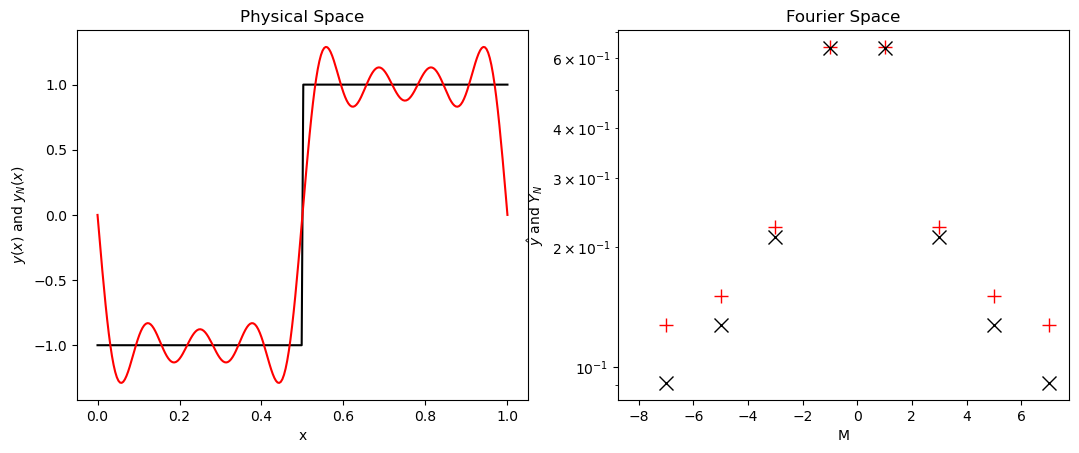

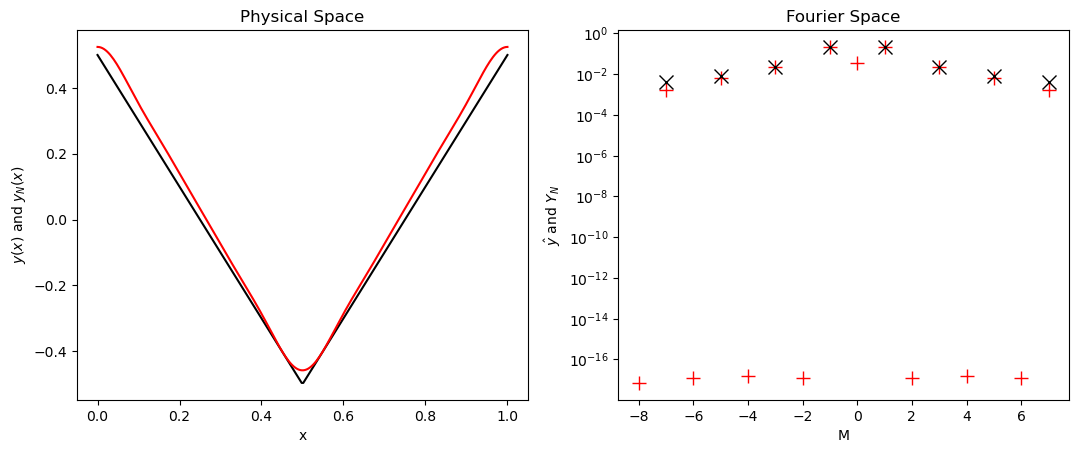

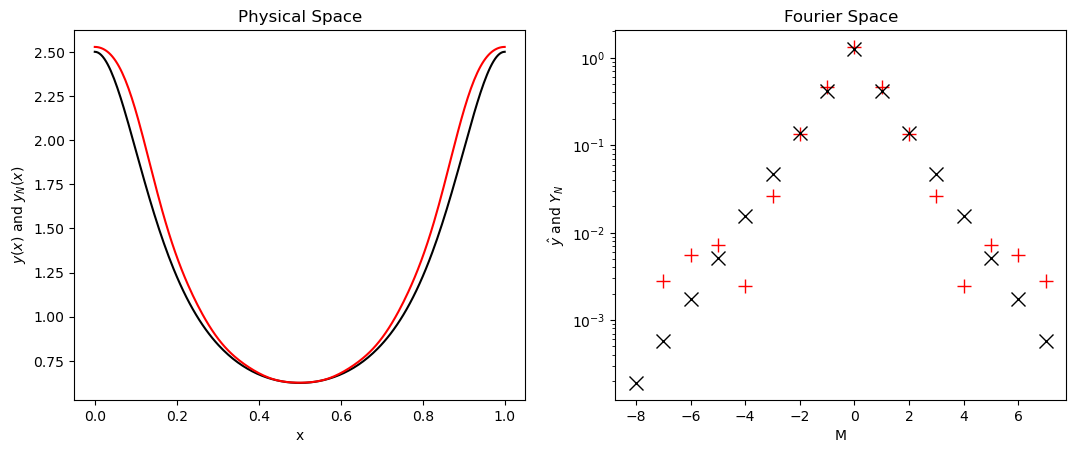

In [184]:
L = 1.0  # panjang domain (interval) yang digunakan, di sini bernilai 1.0

N = 2**4  # jumlah titik grid, 2 pangkat 4 = 16

x = numpy.linspace(0.0, L, N)  # membuat array x dengan N titik dari 0 sampai L

delta_x = L / N  # jarak antar titik grid (step size)

x_fine = numpy.linspace(0.0, L, 2**8)  # grid lebih halus dengan 256 titik untuk visualisasi

M = fft.fftfreq(N, 1.0 / N)  # frekuensi Fourier diskrit untuk N titik

M_odd = M[numpy.nonzero(numpy.ravel(numpy.mod(M, 2)))]  # memilih hanya frekuensi ganjil

k = 2.0 * numpy.pi * M / L  # bilangan gelombang (wave number) terkait frekuensi Fourier

# mendefinisikan tiga fungsi y(x) berbeda
y = [lambda x: numpy.sign(x - 0.5),  # fungsi tanda (step function) bergeser
     lambda x: numpy.abs(2.0 * x - 1.0) - 0.5,  # fungsi segitiga simetris
     lambda x: 1.0 / (1.0 - 0.6 * numpy.cos(2.0 * numpy.pi / L * x))]  # fungsi periodik berbasis cosinus

# mendefinisikan bentuk analitik dari koefisien Fourier untuk tiap fungsi
y_hat = [lambda M:-2.0j / (numpy.pi * M),  # koefisien Fourier untuk fungsi tanda
         lambda M:2.0 / (numpy.pi * M)**2,  # koefisien Fourier untuk fungsi segitiga
         lambda M:1.25 * 3.0**(-numpy.abs(M))]  # koefisien Fourier untuk fungsi periodik cosinus

# loop untuk setiap fungsi y
for (i, y) in enumerate(y):
    Y = fft.fft(y(x))  # menghitung FFT dari fungsi y pada grid x
    y_inv = numpy.zeros(x_fine.shape[0])  # inisialisasi array untuk invers Fourier (rekonstruksi)
    for m in range(N):  # loop untuk setiap mode Fourier
        y_inv += ((Y[m] / N) * numpy.exp(1.0j * k[m] * (x_fine - 1.0 / (2.0 * N)))).real  # rekonstruksi fungsi dari koefisien Fourier

    fig = plt.figure()  # membuat figure baru
    fig.set_figwidth(fig.get_figwidth() * 2)  # memperlebar ukuran figure
    axes = fig.add_subplot(1, 2, 1)  # subplot pertama (ruang fisik)
    axes.plot(x_fine, y(x_fine), 'k')  # plot fungsi asli (warna hitam)
    axes.plot(x_fine, y_inv,'r')  # plot hasil rekonstruksi Fourier (warna merah)
    axes.set_xlabel("x")  # label sumbu x
    axes.set_ylabel("$y(x)$ and $y_N(x)$")  # label sumbu y
    axes.set_title("Physical Space")  # judul subplot pertama

    axes = fig.add_subplot(1, 2, 2)  # subplot kedua (ruang Fourier)
    axes.semilogy(M, numpy.abs(Y) / N, '+r', markersize=10)  # plot spektrum Fourier hasil FFT (skala log)
    if i != 2:  # untuk dua fungsi pertama
        axes.semilogy(M_odd, numpy.abs(y_hat[i](M_odd)) , 'xk', markersize=10)  # plot koefisien Fourier analitik pada frekuensi ganjil
    else:  # untuk fungsi ketiga
        axes.semilogy(M, numpy.abs((y_hat[i](M))), 'xk', markersize=10)  # plot koefisien Fourier analitik pada semua frekuensi
    axes.set_xlabel("M")  # label sumbu x (frekuensi)
    axes.set_ylabel("$\hat{y}$ and $Y_N$")  # label sumbu y (koefisien Fourier)
    axes.set_title("Fourier Space")  # judul subplot kedua

plt.show()  # menampilkan semua plot

Secara praktis, kita dapat mengatakan bahwa semakin halus fungsi, semakin sedikit koefisien Fourier yang perlu kita miliki untuk mendekati fungsi $y(x)$.

### Sifat-sifat DFT

Misalkan $\mathbf{y}$ adalah vektor nilai titik kisi $y_i$, maka DFT dan invers DFT dapat ditulis sebagai operator matriks
$$
    \mathbf{Y} = DFT(\mathbf{y}) = N^{1/2} \mathbf{F} \mathbf{y} \\
    \mathbf{y} = DFT^{-1}(\mathbf{Y}) = N^{1/2} \mathbf{F}^\ast \mathbf{Y}.
$$
Di sini $\mathbf{Y}$ adalah DFT dari $\mathbf{y}$,
$$
    F_{mn} = N^{-1/2} \exp(-2 \pi i (m - 1)(n - 1)),
$$
dan $\mathbf{F}^\ast$ adalah konjugat transpos dari $\mathbf{F}$.

Dari sini kita juga dapat menurunkan *identitas Parseval* untuk transformasi diskret
$$\begin{aligned}
    \sum^N_{m=1} \frac{|Y^2_m|}{N} &= \frac{\mathbf{Y}^\ast \mathbf{Y}}{N} \\
    &= \mathbf{y}^\ast \mathbf{F}^\ast \mathbf{F} \mathbf{y} \\
    &= \mathbf{y}^\ast \mathbf{y} \\
    &= \sum^N_{n=1} |y^2_n|
\end{aligned}$$
menggunakan fakta bahwa $\mathbf{F}$ adalah matriks uniter (yaitu $\mathbf{F}^\ast \mathbf{F} = \mathbf{F} \mathbf{F}^\ast = \mathbf{I}$).

DFT juga memenuhi teorema konvolusi sehingga
$$
    DFT(w \ast y) = W_m Y_m
$$
di mana
$$
    (w \ast y)_n = \sum^N_{p=1} w_p y_{n-p}
$$
adalah konvolusi dari $w$ dan $y$.

**Teorema** Kehalusan sebuah fungsi dan peluruhan koefisien Fourier-nya.

Misalkan $u \in L^2(\mathbb R)$ memiliki transformasi Fourier $\hat{u}$, maka
1. Jika $u$ memiliki $p-1$ turunan kontinu dalam $L^2(\mathbb R)$ untuk beberapa $p \geq 0$ dan turunan ke-$p$ dengan variasi terbatas maka
$$
    \hat{u~}(k) = \mathcal{O}(|k|^{-p-1} ) \quad \text{sebagai} \quad |k| \rightarrow \infty.
$$
1. Jika $u$ memiliki tak hingga banyak turunan kontinu dalam $L^2(\mathbb R)$ maka
$$
    \hat{u~}(k) = \mathcal{O}(|k|^{-m} ) \quad \text{sebagai} \quad |k| \rightarrow \infty
$$
untuk setiap $m \geq 0$, ini juga dikenal sebagai *konvergensi spektral*. Konvers juga berlaku.
1. Jika terdapat $a, c > 0$ sedemikian sehingga $u$ dapat diperluas menjadi fungsi analitik dalam strip kompleks $|\Im(z)| < a$ dengan $\| u(\cdot + i y) \| \leq c$ secara seragam untuk semua $y \in (-a, a)$, di mana $\| u(\cdot + i y) \|$ adalah norma $L^2$ sepanjang garis horizontal $\Im(z) = y$, maka $u_a(k) \in L^2(\mathbb R)$, di mana $u_a(k) = e^{a |k|} \hat{u}(k)$. Konvers juga berlaku.
1. Jika $u$ dapat diperluas menjadi fungsi entire (yaitu analitik di seluruh bidang kompleks) dan terdapat $a > 0$ sedemikian sehingga $|u(z)| = \mathcal{O}(e^{a|z|})$ saat $z \rightarrow \infty$ untuk semua nilai kompleks $z \in \mathbb C$ maka $\hat{u}$ memiliki dukungan kompak di dalam $[-a, a]$. Konvers juga berlaku.

### Diferensiasi

Ingat bahwa transformasi Fourier dari sebuah turunan mengubah turunan menjadi ekspresi aljabar:
$$
    \widehat{(u_x)} = i \xi \hat{u~}.
$$
Kita dapat memanfaatkan ini juga dalam kasus diskret.

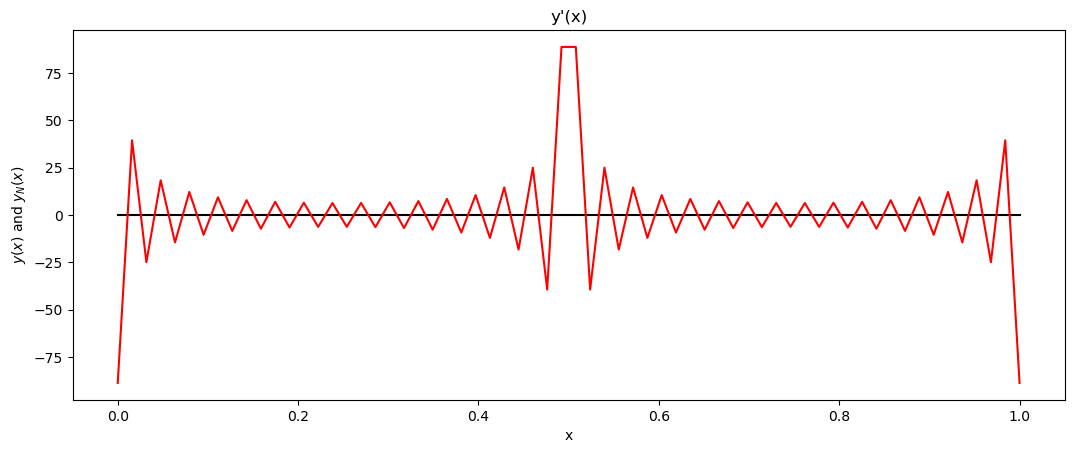

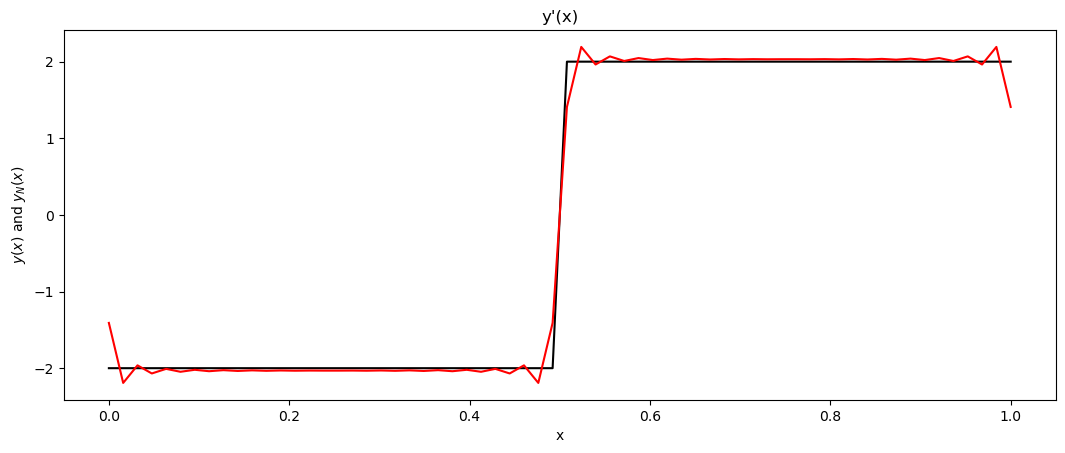

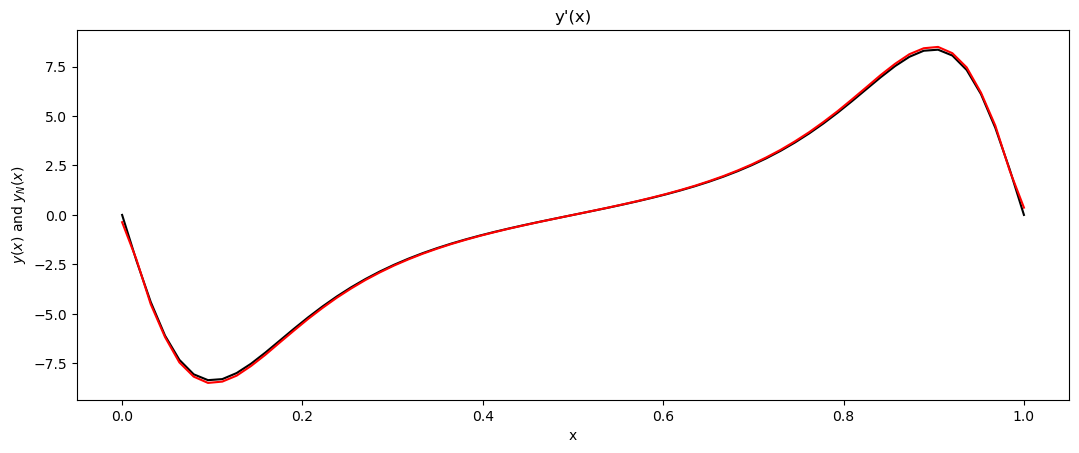

In [185]:
L = 1.0  # panjang domain interval, di sini bernilai 1.0

N = 2**6  # jumlah titik grid, 2 pangkat 6 = 64

x = numpy.linspace(0.0, L, N)  # membuat array x dengan N titik dari 0 sampai L

M = fft.fftfreq(N, 1.0 / N)  # frekuensi Fourier diskrit untuk N titik

M_odd = M[numpy.nonzero(numpy.ravel(numpy.mod(M, 2)))]  # memilih frekuensi ganjil

k = 2.0 * numpy.pi * M / L  # bilangan gelombang (wave number) terkait frekuensi Fourier

# mendefinisikan tiga fungsi y(x)
y_funcs = [lambda x: numpy.sign(x - 0.5),  # fungsi tanda (step function) bergeser
           lambda x: numpy.abs(2.0 * x - 1.0) - 0.5,  # fungsi segitiga simetris
           lambda x: 1.0 / (1.0 - 0.6 * numpy.cos(2.0 * numpy.pi / L * x))]  # fungsi periodik berbasis cosinus

# mendefinisikan turunan analitik dari masing-masing fungsi y(x)
y_prime_funcs = [lambda x: numpy.zeros(x.shape[0]),  # turunan fungsi tanda (nol kecuali di titik diskontinuitas)
                 lambda x: 2.0 * numpy.sign(x - 0.5),  # turunan fungsi segitiga (piecewise konstan)
                 lambda x: -1.2 * numpy.pi / L * numpy.sin(2.0 * numpy.pi / L * x) / (1.0 - 0.6 * numpy.cos(2.0 * numpy.pi / L * x))**2]  # turunan fungsi periodik cosinus

# loop untuk setiap fungsi y
for (i, y) in enumerate(y_funcs):
    Y = fft.fft(y(x))  # menghitung FFT dari fungsi y pada grid x
    y_prime = fft.ifft(1.0j * k * Y).real  # menghitung turunan numerik via Fourier (dengan mengalikan koefisien Fourier dengan i*k)

    fig = plt.figure()  # membuat figure baru
    fig.set_figwidth(fig.get_figwidth() * 2)  # memperlebar ukuran figure
    axes = fig.add_subplot(1, 1, 1)  # subplot tunggal
    axes.plot(x, y_prime_funcs[i](x), 'k')  # plot turunan analitik (warna hitam)
    axes.plot(x, y_prime,'r')  # plot turunan hasil metode Fourier (warna merah)
    axes.set_xlabel("x")  # label sumbu x
    axes.set_ylabel("$y(x)$ and $y_N(x)$")  # label sumbu y
    axes.set_title("y'(x)")  # judul subplot

plt.show()  # menampilkan semua plot

Kita juga dapat menulis operasi ini sebagai operasi matriks (dengan asumsi fungsi periodik):
$$\begin{aligned}
    y'(x) \approx N^{-1/2} \mathbf{F}^\ast i \mathbf{K} \mathbf{Y} = N^{-1/2} \mathbf{F}^\ast i \mathbf{K} N^{1/2} \mathbf{F} \mathbf{y} = \mathbf{D} \mathbf{y}
\end{aligned}$$
di mana $D \equiv \mathbf{F}^\ast (i \mathbf{K}) \mathbf{F}$ adalah *matriks diferensiasi pseudospektral Fourier*. Matriks ini nyata, padat, anti-simetri, dan $N \times N$. Matriks $\mathbf{K} \equiv \mathrm{diag}(\mathbf{k})$.

Juga, karena $\mathbf{F}$ bersifat uniter, kita dapat menyusun beberapa turunan dengan hanya menerapkan matriks berkali-kali untuk menemukan turunan ke-$p$.
$$
    D^p = (\mathbf{F}^\ast i \mathbf{K} \mathbf{F})^p = \mathbf{F}^\ast (i \mathbf{K})^p \mathbf{F}
$$

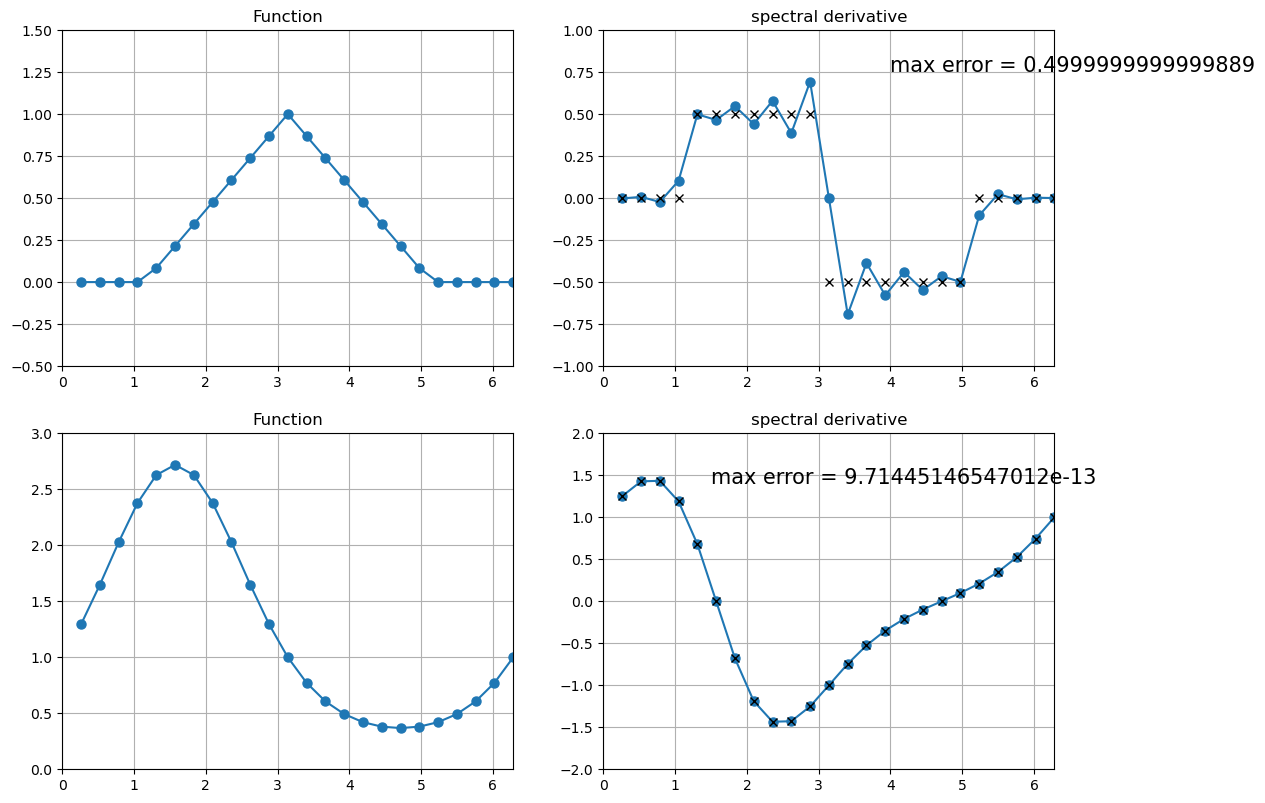

In [186]:
# Example Program 4 from Trefethen - Spectral Methods in MATLAB

import scipy.linalg as linalg  # mengimpor modul linalg dari SciPy untuk operasi aljabar linear

N = 24  # jumlah titik grid
delta_x = 2.0 * numpy.pi / N  # jarak antar titik grid (step size)
x = numpy.linspace(delta_x, delta_x * N, N)  # membuat array x dari delta_x sampai 2π dengan N titik

# Gunakan matriks diferensiasi untuk menghitung turunan
column = numpy.empty(N)  # inisialisasi kolom pertama matriks Toeplitz
column[1:] = 0.5*(-1.0)**(numpy.arange(1, N)) * 1.0 / numpy.tan(numpy.arange(1, N) * delta_x / 2.0)  
# isi kolom dengan formula turunan spektral
column[0] = 0.0  # elemen pertama bernilai nol
index_array = numpy.empty(N, dtype=int)  # array indeks untuk simetri Toeplitz
index_array[0] = 0
index_array[1:] = numpy.flipud(numpy.arange(1, N))  # membalik urutan indeks
D = linalg.toeplitz(column, column[index_array])  # membentuk matriks Toeplitz (matriks diferensiasi)

fig, axes = plt.subplots(2, 2)  # membuat figure dengan 2x2 subplot
fig.set_figwidth(fig.get_figwidth() * 2)  # memperlebar figure
fig.set_figheight(fig.get_figheight() * 2)  # mempertinggi figure

# Diferensiasi fungsi "hat" (segitiga)
v = numpy.where(1 - numpy.abs(x - numpy.pi) / 2.0 > 0.0, 1 - numpy.abs(x - numpy.pi) / 2.0, 0.0)  
# mendefinisikan fungsi hat
v_prime =  numpy.ones(x.shape) * (1 - numpy.abs(x - numpy.pi) / 2.0 > 0.0) * (x < numpy.pi) * 0.5 + \
          -numpy.ones(x.shape) * (1 - numpy.abs(x - numpy.pi) / 2.0 > 0.0) * (x > numpy.pi) * 0.5  
# turunan analitik fungsi hat (piecewise konstan)

axes[0, 0].plot(x, v, '.-', markersize=13)  # plot fungsi hat
axes[0, 0].set_xlim((0, 2 * numpy.pi))  # batas sumbu x
axes[0, 0].set_ylim((-0.5, 1.5))  # batas sumbu y
axes[0, 0].set_title("Function")  # judul subplot
axes[0, 0].grid(True)  # menyalakan grid

axes[0, 1].plot(x, numpy.dot(D, v), '.-', markersize=13)  # plot turunan spektral (hasil matriks D * v)
axes[0, 1].plot(x, v_prime, 'kx')  # plot turunan analitik (tanda silang hitam)
axes[0, 1].set_xlim((0, 2*numpy.pi))
axes[0, 1].set_ylim((-1, 1))
axes[0, 1].set_title('spectral derivative')  # judul subplot
axes[0, 1].grid(True)
error = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.inf)  # menghitung error maksimum (norma tak hingga)
axes[0, 1].text(4.0, 0.75, "max error = %s" % error, fontsize=15)  # menampilkan error di plot

# Diferensiasi fungsi exp(sin(x))
v = numpy.exp(numpy.sin(x))  # fungsi exp(sin(x))
v_prime = numpy.cos(x) * v  # turunan analitik exp(sin(x)) = cos(x)*exp(sin(x))
axes[1, 0].plot(x, v, '.-', markersize=13)  # plot fungsi
axes[1, 0].set_xlim((0, 2 * numpy.pi))
axes[1, 0].set_ylim((0.0, 3.0))
axes[1, 0].set_title("Function")
axes[1, 0].grid(True)

axes[1, 1].plot(x, numpy.dot(D, v), '.-', markersize=13)  # plot turunan spektral
axes[1, 1].plot(x, v_prime, 'kx')  # plot turunan analitik
axes[1, 1].set_xlim((0, 2*numpy.pi))
axes[1, 1].set_ylim((-2, 2))
axes[1, 1].set_title('spectral derivative')
axes[1, 1].grid(True)
error = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.inf)  # error maksimum
axes[1, 1].text(1.5, 1.4, "max error = %s" % error, fontsize=15)  # tampilkan error di plot

plt.show()  # menampilkan semua plot

### Metode Spektral

Kita juga dapat menerapkan pendekatan di atas jika kondisi batas periodik digunakan dan solusi halus diharapkan. Mari kita periksa ini melalui sebuah contoh.

Kita ingin menyelesaikan persamaan adveksi dengan kecepatan variabel
$$
    u_t + c(x) u_x = 0, \quad \Omega = [0, 2 \pi]
$$
dengan kondisi batas periodik dan kondisi awal
$$
    u(x,0) = \exp(-100 (x - 1)^2)
$$
dan kecepatan variabel
$$
    c(x) = 1/5 + \sin^2(x - 1)
$$

Sekarang mari kita bangun metode berdasarkan leapfrog dan pendekatan diferensiasi di atas. Perhatikan bahwa dalam perspektif metode garis kita akan memiliki
$$
    \frac{U^{n+1}_j - U^{n+1}_j}{2 \Delta t} = f(U^n) = -c(x_j) (D U^n)_j
$$
di mana di sini kita menggunakan matriks diferensiasi di atas alih-alih beda terpusat. Kita juga dapat menggunakan metode (yang lebih efisien) berdasarkan mengetahui transformasi Fourier dari turunan. Perhatikan bahwa kita menggunakan aproksimasi di sini untuk memulai metode.

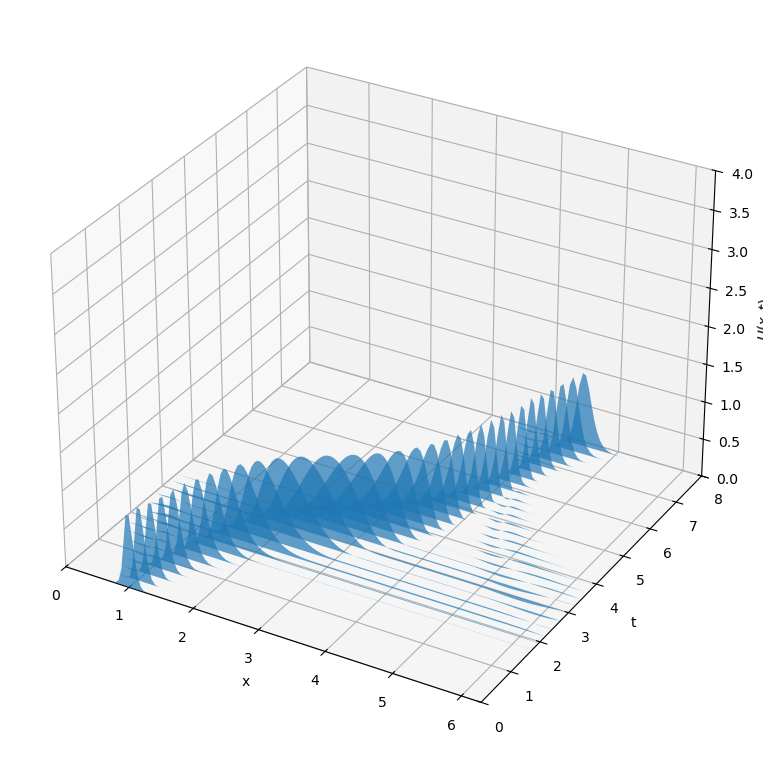

In [187]:
from mpl_toolkits.mplot3d import Axes3D  # modul untuk membuat plot 3D dengan matplotlib
import matplotlib.collections  # modul untuk koleksi objek grafis (misalnya PolyCollection)
import matplotlib.colors  # modul untuk manipulasi warna

# Membandingkan pendekatan pseudo-spectral dengan finite difference
# untuk masalah adveksi dengan koefisien variabel

# Membuat domain
N = 128  # jumlah titik grid
L = 2.0 * numpy.pi  # panjang domain (0 sampai 2π)
delta_x = L / N  # jarak antar titik grid
delta_t = delta_x / 4.0  # langkah waktu (time step)
x = numpy.linspace(delta_x, delta_x * N, N)  # grid x dari delta_x sampai 2π
M = fft.fftfreq(N, 1.0 / N)  # frekuensi Fourier diskrit
k = 2.0 * numpy.pi * M / L  # bilangan gelombang (wave number)
c = 0.2 + numpy.sin(x - 1.0)**2  # koefisien adveksi variabel

# Matriks diferensiasi (Toeplitz)
column = numpy.empty(N)  # kolom pertama matriks
column[1:] = 0.5*(-1.0)**(numpy.arange(1, N)) * 1.0 / numpy.tan(numpy.arange(1, N) * delta_x / 2.0)  
column[0] = 0.0
index_array = numpy.empty(N, dtype=int)
index_array[0] = 0
index_array[1:] = numpy.flipud(numpy.arange(1, N))  # indeks dibalik untuk simetri
D = linalg.toeplitz(column, column[index_array])  # matriks Toeplitz sebagai operator turunan

# Kondisi awal (Gaussian bump)
U = numpy.exp(-100.0 * (x - 1.0)**2)  # solusi saat t=0
U_old = numpy.exp(-100.0 * (x - 0.2 * delta_t - 1.0)**2)  # solusi pada langkah sebelumnya (untuk skema dua langkah)
t_final = 8.0  # waktu akhir simulasi
num_steps = int(numpy.ceil(t_final / delta_t))  # jumlah langkah waktu
plot_interval = 20  # interval output untuk visualisasi
t = 0.0  # waktu awal
verts = []  # daftar untuk menyimpan kurva solusi
t_output = []  # daftar waktu output

# Loop waktu
for n in range(num_steps):
    # Diskretisasi langsung turunan via FFT (dikomentari)
    # U_hat = fft.fft(U)
    # U_prime_hat = 1.0j * k * U_hat
    # U_prime = fft.ifft(U_prime_hat).real

    # Turunan dengan matriks diferensiasi
    U_prime = numpy.dot(D, U)  # menghitung turunan U
    U_new = U_old - 2.0 * delta_t * c * U_prime  # skema eksplisit untuk adveksi
    U_old = U  # update solusi lama
    U = U_new  # update solusi baru

    t += delta_t  # update waktu
    if numpy.mod(n, plot_interval) == 0:  # simpan hasil setiap beberapa langkah
        t_output.append(t)
        verts.append(list(zip(x, U)))  # simpan kurva (x, U)

# Membuat koleksi poligon untuk visualisasi 3D
cc = lambda arg:  matplotlib.colors.colorConverter.to_rgba(arg, alpha=0.6)  # fungsi konversi warna
poly = matplotlib.collections.PolyCollection(verts)  # koleksi poligon dari kurva solusi
poly.set_alpha(0.7)  # transparansi

# Membuat plot 3D
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
axes = fig.add_subplot(1, 1, 1, projection='3d')  # subplot 3D
axes.add_collection3d(poly, zs=t_output, zdir='y')  # tambahkan poligon dengan sumbu waktu sebagai y
axes.set_xlabel("x")  # label sumbu x
axes.set_xlim3d(0.0, 2.0 * numpy.pi)  # batas sumbu x
axes.set_ylabel("t")  # label sumbu y (waktu)
axes.set_ylim3d(0.0, 8.0)  # batas sumbu y
axes.set_zlabel("$U(x,t)$")  # label sumbu z (solusi)
axes.set_zlim(0.0, 4)  # batas sumbu z

plt.show()  # tampilkan plot

## Penyelesai Poisson Berbasis FFT

Dalam kuliah tentang metode iteratif untuk masalah Poisson sebelumnya disebutkan secara singkat bahwa ada cara untuk menyelesaikan masalah Poisson berdasarkan FFT. Di sini kita akan mengeksplorasi beberapa gagasan di balik metode kuat ini.

Pertimbangkan terlebih dahulu masalah Poisson satu dimensi yang didefinisikan sebagai
$$
    u_{xx} = f(x), \quad \Omega = [0, L]
$$
di mana $f(x)$ periodik beserta kondisi batas periodiknya.

Pertimbangkan solusi yang merupakan kombinasi linear dari basis Fourier hingga
$$
    u(x) \approx \frac{1}{N} \sum^N_{n=1} U_n \exp(i k_n x)
$$
di mana kita memiliki
$$
    k_n = \frac{2 \pi}{L} \left\{ \begin{aligned} 
        n - 1, & & 1 \leq n \leq N/2 \\
        n - N - 1, & & N/2 + 1 \leq n \leq N.
    \end{aligned} \right .
$$

Sekarang pertimbangkan $N$ titik kolokasi Fourier
$$
    x_j = \frac{(j-1) L}{N}, \quad j = 1, \ldots, N
$$
dan vektor terkait $\mathbf{u} = [u(x_j)]_j$ dan $\mathbf{f} = [f(x_j)]_j$. Mengambil transformasi Fourier dari kedua sisi PDE asli kita memperoleh
$$\begin{aligned}
    (-i k_n)^2 \hat{u~}(k) &= \hat{f}(k) \\
    \hat{u~}(k) &= -\frac{\hat{f~}(k)}{k_n^2}.
\end{aligned}$$
Mengambil transformasi invers dari kedua sisi akan memberi solusi. Dalam kasus diskret kita memiliki
$$
    \hat{\mathbf{f}~} = \text{DFT}(\mathbf{f}) \\
    U_n = -\frac{\hat{\mathbf{f}~}}{k_n^2} \\
    \mathbf{u} = \text{IDFT}\left(-\frac{\hat{\mathbf{f}~}}{k_n^2}\right). \\
$$

Salah satu masalah yang akan kita hadapi adalah bahwa $k_n = 0$ untuk $n=1$. Kita dapat mengasumsikan bahwa $F_1 = 0$ sehingga kita setidaknya dapat memperlakukan komponen ini secara unik (secara teknis masih akan ada $0/0$ tetapi ada penanganan untuk kasus ini). Pertanyaannya adalah apakah kita seharusnya benar-benar mengikuti pendekatan ini.

Batasan bahwa $f_1 = 0$ sebenarnya adalah kondisi untuk permasalahan Poisson yang teratur pada domain periodik. Komponen ini mewakili nilai rata-rata fungsi $f(x)$ dan untungnya dapat dengan mudah dipisahkan dari fungsi tersebut. Sebenarnya sistemnya juga tidak tertutup dalam kasus ini dan ada tak hingga banyak solusi yang berbeda oleh nilai rata-rata (solusi ditentukan hingga konstanta aditif). Di sini kita sebenarnya menyatakan bahwa kita mencari solusi di mana konstanta ini identik nol.

C:\Users\WIND11\AppData\Local\Temp\ipykernel_38304\653763056.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  U_hat[1:] = -F[1:] / k[1:]**2  # solusi Fourier: U_hat = -F/k^2 (untuk k ≠ 0)


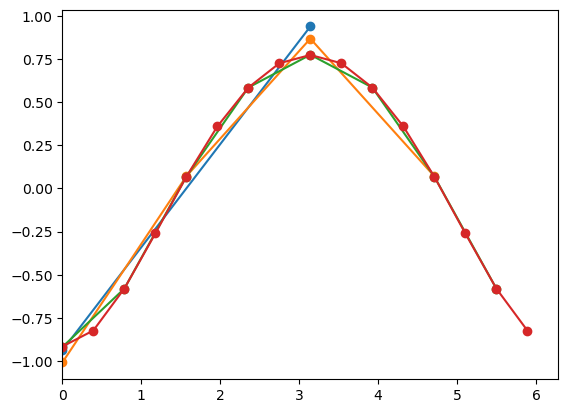

In [190]:
# Fourier spectral method for the Poisson problem

L = 2.0 * numpy.pi  # panjang domain (0 sampai 2π)
f = lambda x: 1.0 / (1.0 - 0.6 * numpy.cos(2.0 * numpy.pi * x / L))  
# fungsi sumber f(x) yang akan digunakan dalam persamaan Poisson

fig, axes = plt.subplots(1, 1)  # membuat figure dengan satu subplot
for N in [2, 4, 8, 16]:  # loop untuk berbagai jumlah titik grid
    delta_x = L / N  # jarak antar titik grid
    delta_t = delta_x / 4.0  # langkah waktu (tidak digunakan langsung di sini, tapi diset)
    x = numpy.linspace(0.0, delta_x * (N - 1), N)  # grid x dari 0 sampai L dengan N titik
    
    # Gunakan FFT untuk menyelesaikan persamaan Poisson
    M = fft.fftfreq(N, 1.0 / N)  # frekuensi Fourier diskrit
    k = 2.0 * numpy.pi * M / L  # bilangan gelombang (wave number)

    F = fft.fft(f(x))  # transformasi Fourier dari f(x)
    if F[0] != 0:  # jika ada komponen rata-rata (mean)
        F = fft.fft(f(x) - F[0])  # hilangkan komponen rata-rata agar solusi Poisson terdefinisi

    U_hat = numpy.empty(N)  # inisialisasi array untuk solusi di ruang Fourier
    U_hat[0] = 0.0  # mode nol diatur ke nol (tidak ada solusi untuk k=0)
    U_hat[1:] = -F[1:] / k[1:]**2  # solusi Fourier: U_hat = -F/k^2 (untuk k ≠ 0)

    U = fft.ifft(U_hat).real  # transformasi balik untuk mendapatkan solusi di ruang fisik

    axes.plot(x, U, 'o-')  # plot solusi U(x) untuk grid N
    axes.set_xlim(0.0, L)  # batas sumbu x dari 0 sampai L

## Metode Spektral Chebyshev

Jadi apa yang terjadi ketika kita tidak berada di domain periodik? Kita dapat memikirkan menggunakan polinomial alih-alih polinomial trigonometri (basis Fourier kita). Namun dari interpolasi kita tahu bahwa menggunakan titik berjarak sama adalah ide buruk.

Sebagai gantinya kita akan mendistribusikan titik interpolasi sedemikian rupa sehingga
$$
    x_j = \cos\left(\frac{j \pi}{N} \right), \quad j=0, 1, \ldots, N,
$$
disebut *titik Chebyshev* jenis kedua.

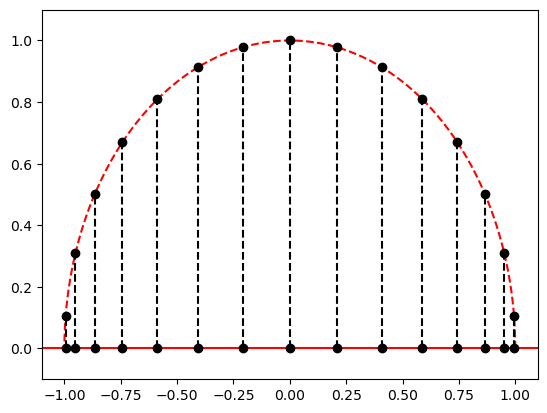

In [191]:
# Distribution of Chebyshev nodes

x = numpy.linspace(0, numpy.pi, 100)  # membuat 100 titik dari 0 sampai π untuk menggambar setengah lingkaran
N = 15  # jumlah node Chebyshev yang akan ditampilkan

fig = plt.figure()  # membuat figure baru
axes = fig.add_subplot(1, 1, 1)  # menambahkan satu subplot

axes.plot(numpy.cos(x), numpy.sin(x), 'r--')  # menggambar setengah lingkaran (garis merah putus-putus)
axes.plot(numpy.linspace(-1.1, 1.1, 100), numpy.zeros(x.shape), 'r')  # menggambar sumbu x (garis merah)

# loop untuk menempatkan node Chebyshev
for k in range(1, N + 1):
    location = [numpy.cos((2.0 * k - 1.0) * numpy.pi / (2.0 * N)),  # koordinat x node Chebyshev
                numpy.sin((2.0 * k - 1.0) * numpy.pi / (2.0 * N))]  # koordinat y node Chebyshev (di lingkaran atas)
    axes.plot(location[0], location[1], 'ko')  # plot node di lingkaran (titik hitam)
    axes.plot(location[0], 0.0, 'ko')  # proyeksi node ke sumbu x
    axes.plot([location[0], location[0]], [0.0, location[1]], 'k--')  # garis vertikal putus-putus dari sumbu x ke lingkaran

axes.set_xlim((-1.1, 1.1))  # batas sumbu x
axes.set_ylim((-0.1, 1.1))  # batas sumbu y
plt.show()  # tampilkan plot

Dengan basis Lagrange kita dapat langsung melihat bagaimana menggunakan titik berjarak sama dibandingkan dengan titik Chebyshev.

True


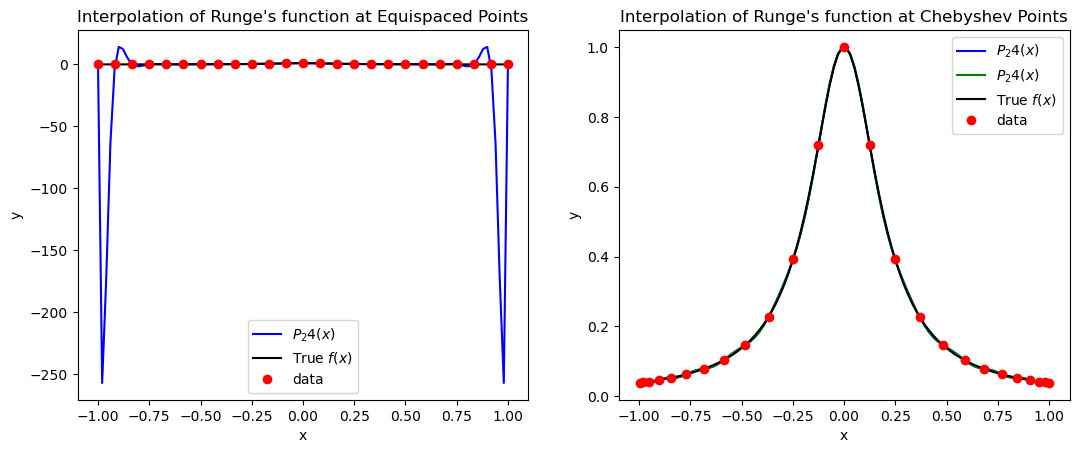

In [192]:
def f(x):
    return 1.0 / (1.0 + 25.0 * x**2)  # fungsi Runge klasik, sering dipakai untuk menguji interpolasi polinomial

# Parameters
x = numpy.linspace(-1, 1, 100)  # grid halus untuk evaluasi fungsi dan interpolasi
num_points = 25  # jumlah titik data untuk interpolasi

# ============================================================
#  Equidistant nodes
equidistant_data = numpy.empty((num_points, 2))  # array untuk menyimpan titik data (x,y)
equidistant_data[:, 0] = numpy.linspace(-1, 1, num_points)  # titik x merata di interval [-1,1]
equidistant_data[:, 1] = f(equidistant_data[:, 0])  # nilai fungsi f(x) di titik-titik tersebut
N = equidistant_data.shape[0] - 1  # derajat polinomial interpolasi (jumlah titik - 1)

lagrange_basis = numpy.ones((N + 1, x.shape[0]))  # inisialisasi basis Lagrange
for i in range(N + 1):  # loop untuk setiap basis
    for j in range(N + 1):  # loop untuk setiap titik
        if i != j:
            lagrange_basis[i, :] *= (x - equidistant_data[j, 0]) / (equidistant_data[i, 0] - equidistant_data[j, 0])  
            # rumus basis Lagrange

# Hitung polinomial interpolasi penuh
P_lagrange = numpy.zeros(x.shape[0])  # inisialisasi polinomial
for n in range(N + 1):
    P_lagrange += lagrange_basis[n, :] * equidistant_data[n, 1]  # kombinasi linear basis dengan nilai data

# ============================================================
#  Chebyshev nodes
chebyshev_data = numpy.empty((num_points, 2))  # array untuk titik Chebyshev
chebyshev_data[:, 0] = numpy.cos((2.0 * numpy.arange(1, num_points + 1) - 1.0) * numpy.pi / (2.0 * num_points))  
# titik Chebyshev di [-1,1]
chebyshev_data[:, 1] = f(chebyshev_data[:, 0])  # nilai fungsi di titik Chebyshev

# Buat interpolan berbasis Chebyshev nodes
lagrange_basis = numpy.ones((N + 1, x.shape[0]))
for i in range(N + 1):
    for j in range(N + 1):
        if i != j:
            lagrange_basis[i, :] *= (x - chebyshev_data[j, 0]) / (chebyshev_data[i, 0] - chebyshev_data[j, 0])  

# Hitung polinomial interpolasi penuh
P_cheby1 = numpy.zeros(x.shape[0])
for n in range(N + 1):
    P_cheby1 += lagrange_basis[n, :] * chebyshev_data[n, 1]

# Fit langsung dengan polinomial Chebyshev
coeff = numpy.polynomial.chebyshev.chebfit(chebyshev_data[:, 0], chebyshev_data[:, 1], N)  # koefisien Chebyshev
P_cheby2 = numpy.polynomial.chebyshev.chebval(x, coeff)  # evaluasi polinomial Chebyshev

# Cek apakah interpolasi Lagrange dan Chebyshev polynomial sama
print(numpy.allclose(P_cheby1, P_cheby2))  # True jika hasilnya identik

# ============================================================
# Plot hasil
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2.0)  # perbesar lebar figure

axes = fig.add_subplot(1, 2, 1)  # subplot pertama: equidistant nodes
axes.plot(x, P_lagrange, 'b', label="$P_%s(x)$" % N)  # polinomial interpolasi
axes.plot(x, f(x), 'k', label="True $f(x)$")  # fungsi asli
axes.plot(equidistant_data[:, 0], equidistant_data[:, 1], 'ro', label="data")  # titik data
axes.set_title("Interpolation of Runge's function at Equispaced Points")
axes.set_xlabel("x")
axes.set_ylabel("y")
axes.legend(loc=8)

axes = fig.add_subplot(1, 2, 2)  # subplot kedua: Chebyshev nodes
axes.plot(x, P_cheby1, 'b', label="$P_%s(x)$" % N)  # interpolasi Lagrange dengan Chebyshev nodes
axes.plot(x, P_cheby2, 'g', label="$P_%s(x)$" % N)  # interpolasi langsung dengan polinomial Chebyshev
axes.plot(x, f(x), 'k', label="True $f(x)$")  # fungsi asli
axes.plot(chebyshev_data[:, 0], chebyshev_data[:, 1], 'ro', label="data")  # titik data
          
axes.set_title("Interpolation of Runge's function at Chebyshev Points")
axes.set_xlabel("x")
axes.set_ylabel("y")
axes.legend(loc=1)

plt.show()  # tampilkan plot

Ada dua jenis node Chebyshev yang keduanya akan kita lihat bekerja sama baik sebagai titik interpolasi.

1. Node Chebyshev jenis pertama (akar)
$$
    x_k = \cos \left (\frac{(2 k - 1) \pi}{2 N} \right ) \quad k = 1, \ldots, N
$$
1. Node Chebyshev jenis kedua (ekstremum)
$$
    x_k = \cos \left( \frac{k \pi}{N} \right) \quad k = 0, \ldots, N
$$

[ 1.          0.80901699  0.30901699 -0.30901699 -0.80901699 -1.        ]
[0.54030231 0.69021008 0.95263298 0.95263298 0.69021008 0.54030231]


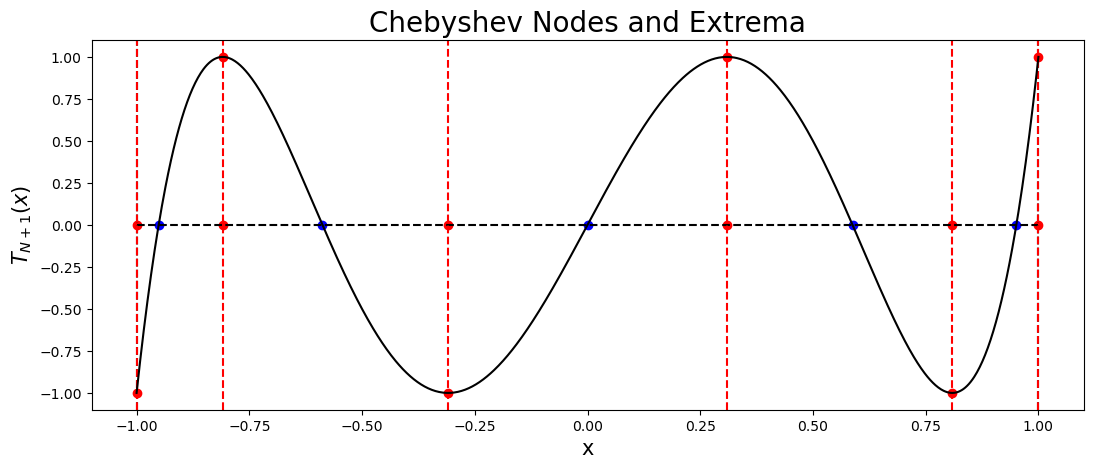

In [193]:
def cheb_poly(x, N):
    """Compute the *N*th Chebyshev polynomial and evaluate it at *x*"""
    T = numpy.empty((3, x.shape[0]))  # array untuk menyimpan nilai polinomial Chebyshev
    T[0, :] = numpy.ones(x.shape)  # T0(x) = 1
    T[1, :] = x  # T1(x) = x
    for k in range(2, N):  # rekursi untuk menghitung T_k(x)
        T[2, :] = 2.0 * x * T[1, :] - T[0, :]  # rumus rekursi Chebyshev: T_k(x) = 2xT_{k-1}(x) - T_{k-2}(x)
        T[0, :] = T[1, :]  # geser nilai untuk iterasi berikutnya
        T[1, :] = T[2, :]  # update nilai polinomial terakhir
    
    return T[2, :]  # hasil polinomial Chebyshev ke-N

N = 5  # derajat polinomial Chebyshev
x_extrema = numpy.cos(numpy.arange(N + 1) * numpy.pi / N)  # titik ekstrem (maksimum/minimum) polinomial Chebyshev
x_nodes = numpy.cos((2.0 * numpy.arange(1, N + 1) - 1.0) / (2.0 * N) * numpy.pi)  # node Chebyshev untuk interpolasi

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
axes = fig.add_subplot(1, 1, 1)

# Plot titik-titik
axes.plot(x_extrema, numpy.zeros(N+1), 'ro')  # titik ekstrem (merah)
axes.plot(x_nodes, numpy.zeros(N), 'bo')  # node Chebyshev (biru)

# Plot garis bantu
axes.plot((-1.0, -1.0), (-1.1, 1.1), 'k--')  # garis vertikal di x=-1
axes.plot((1.0, 1.0), (-1.1, 1.1), 'k--')  # garis vertikal di x=1
axes.plot((-1.0, 1.0), (0.0, 0.0), 'k--')  # garis horizontal di y=0
for i in range(x_extrema.shape[0]):  # loop untuk setiap titik ekstrem
    axes.plot((x_extrema[i], x_extrema[i]), (-1.1, 1.1), 'r--')  # garis vertikal merah di titik ekstrem
    axes.plot(x_extrema[i], cheb_poly(x_extrema, N + 1)[i], 'ro')  # plot nilai polinomial di titik ekstrem

print(x_extrema)  # cetak koordinat titik ekstrem
print(numpy.cos(x_extrema))  # cetak nilai cosinus dari titik ekstrem

# Plot polinomial Chebyshev
x_hat = numpy.linspace(-1, 1, 1000)  # grid halus untuk evaluasi
axes.plot(x_hat, cheb_poly(x_hat, N + 1), 'k')  # plot polinomial Chebyshev ke-(N+1)
axes.set_xlim((-1.1, 1.1))  # batas sumbu x
axes.set_ylim((-1.1, 1.1))  # batas sumbu y

# Label
axes.set_title("Chebyshev Nodes and Extrema", fontsize="20")
axes.set_xlabel("x", fontsize="15")
axes.set_ylabel("$T_{N+1}(x)$", fontsize="15")

plt.show()  # tampilkan plot

Properti menarik lain dari node Chebyshev adalah bahwa mereka bersarang dengan periode berbeda. Node jenis pertama bersarang dengan faktor 3 sedangkan node jenis kedua bersarang setiap 2. Ini dapat berguna jika Anda sudah berusaha mendapatkan evaluasi fungsi pada himpunan node dengan resolusi rendah namun ingin meningkatkan jumlah titik yang digunakan. Jika Anda menggunakan faktor bersarang ini, Anda dapat mempertahankan lokasi node dan data Anda sambil tetap meningkatkan resolusi.

Text(0.5, 1.0, 'Chebyshev Nodes Second-Kind Nesting')

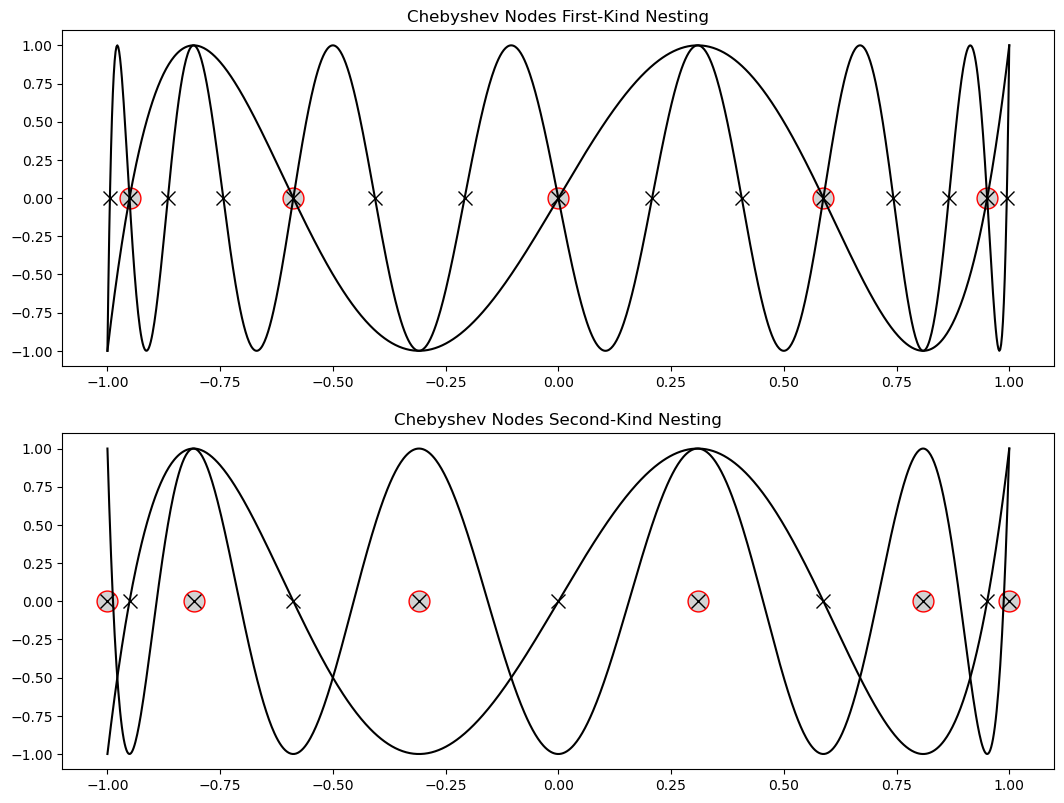

In [194]:
# First-kind Nesting (3 x)
fig = plt.figure()  # membuat figure baru
fig.set_figwidth(fig.get_figwidth() * 2)  # memperlebar figure
fig.set_figheight(fig.get_figheight() * 2)  # mempertinggi figure
axes = fig.add_subplot(2, 1, 1)  # subplot pertama (untuk first-kind nesting)

N = 5  # jumlah node awal
factor = 3  # faktor nesting (3 kali lebih banyak node)
x_1 = numpy.cos((2.0 * numpy.arange(1, N + 1) - 1.0) / (2.0 * N) * numpy.pi)  
# node Chebyshev first-kind untuk N titik
x_2 = numpy.cos((2.0 * numpy.arange(1, factor * N + 1) - 1.0) / (2.0 * factor * N) * numpy.pi)  
# node Chebyshev first-kind untuk factor*N titik

axes.plot(x_1, numpy.zeros(N), "o", color="r", markerfacecolor="lightgray", markersize="15")  # node awal (merah)
axes.plot(x_2, numpy.zeros(N * factor), 'kx', markersize="10")  # node hasil nesting (hitam)

x_hat = numpy.linspace(-1, 1, 1000)  # grid halus untuk evaluasi polinomial
axes.plot(x_hat, cheb_poly(x_hat, N + 1), 'k')  # polinomial Chebyshev derajat N+1
axes.plot(x_hat, cheb_poly(x_hat, factor * N + 1), 'k')  # polinomial Chebyshev derajat factor*N+1
axes.set_xlim((-1.1, 1.1))  # batas sumbu x
axes.set_ylim((-1.1, 1.1))  # batas sumbu y
axes.set_title("Chebyshev Nodes First-Kind Nesting")  # judul subplot pertama

# Second-kind Nesting (2 x)
axes = fig.add_subplot(2, 1, 2)  # subplot kedua (untuk second-kind nesting)
N = 5
factor = 2
x_1 = numpy.cos(numpy.arange(N + 1) * numpy.pi / N)  # node Chebyshev second-kind untuk N titik
x_2 = numpy.cos(numpy.arange(factor * N + 1) * numpy.pi / (factor * N))  # node Chebyshev second-kind untuk factor*N titik

axes.plot(x_1, numpy.zeros(N + 1), "o", color="r", markerfacecolor="lightgray", markersize="15")  # node awal (merah)
axes.plot(x_2, numpy.zeros(N * factor + 1), 'kx', markersize="10")  # node hasil nesting (hitam)

x_hat = numpy.linspace(-1, 1, 1000)
axes.plot(x_hat, cheb_poly(x_hat, N + 1), 'k')  # polinomial Chebyshev derajat N+1
axes.plot(x_hat, cheb_poly(x_hat, factor * N + 1), 'k')  # polinomial Chebyshev derajat factor*N+1
axes.set_xlim((-1.1, 1.1))
axes.set_ylim((-1.1, 1.1))
axes.set_title("Chebyshev Nodes Second-Kind Nesting")  # judul subplot kedua

Salah satu cara untuk mengukur optimalitas node Chebyshev sebagai himpunan titik interpolasi adalah dengan mempertimbangkan fungsi Lebesgue
$$\lambda_N(x) = \sum_{i=0}^N \left| \ell_i(x) \right|$$
di mana $\ell_i(x)$ adalah fungsi basis Lagrange untuk himpunan titik $x_i$ tertentu. Nilai maksimum fungsi Lebesgue disebut konstanta Lebesgue $\Lambda_n$ dan jelas terkait dengan interpolasi Lagrange karena memberikan taksiran pertama untuk galat interpolasi. Sayangnya, $\Lambda_N$ tidak dibatasi secara seragam terlepas dari node yang digunakan seperti yang dapat ditunjukkan bahwa
$$
    \Lambda_N > \mathcal{O}(\log N) \quad \text{sebagai} \quad N \rightarrow \infty
$$
Perhatikan bahwa $\Lambda_n$ adalah norma tak hingga dari operator linear yang memetakan data ke interpolan pada kisi dan interval yang diberikan.

Jika kita menghitung fungsi-fungsi ini untuk titik berjarak sama dan masing-masing jenis node Chebyshev, kita dapat melihat mengapa Chebyshev mungkin jauh lebih baik untuk interpolasi.

C:\Users\WIND11\AppData\Local\Temp\ipykernel_38304\2404399952.py:34: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[i].set_ylim((0.0, y_max + 0.1))  # set batas sumbu y


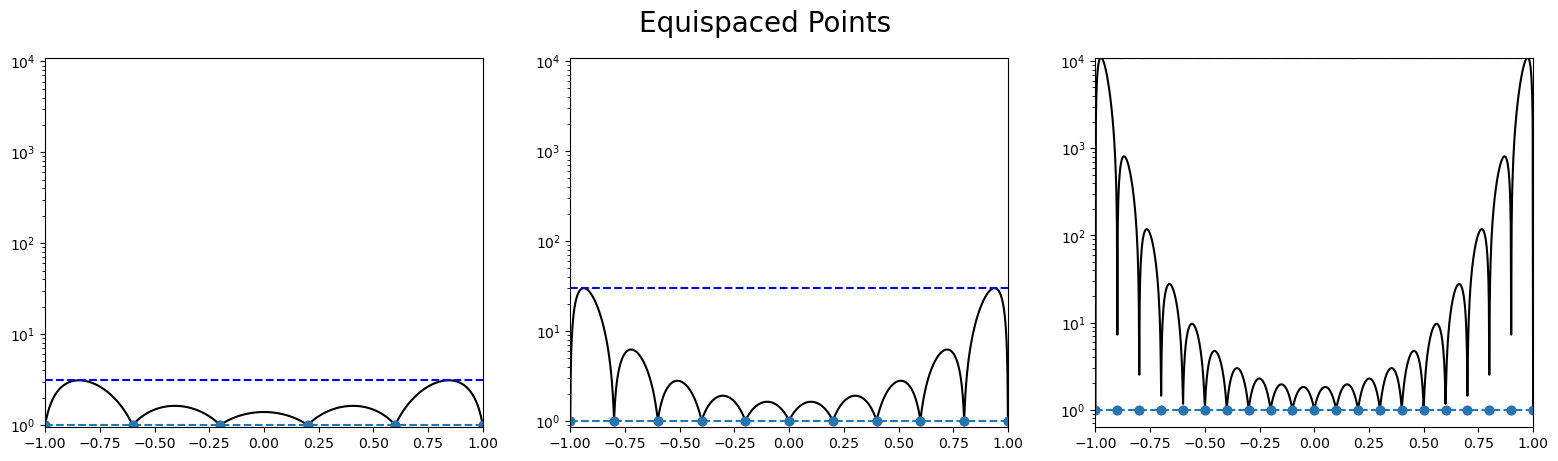

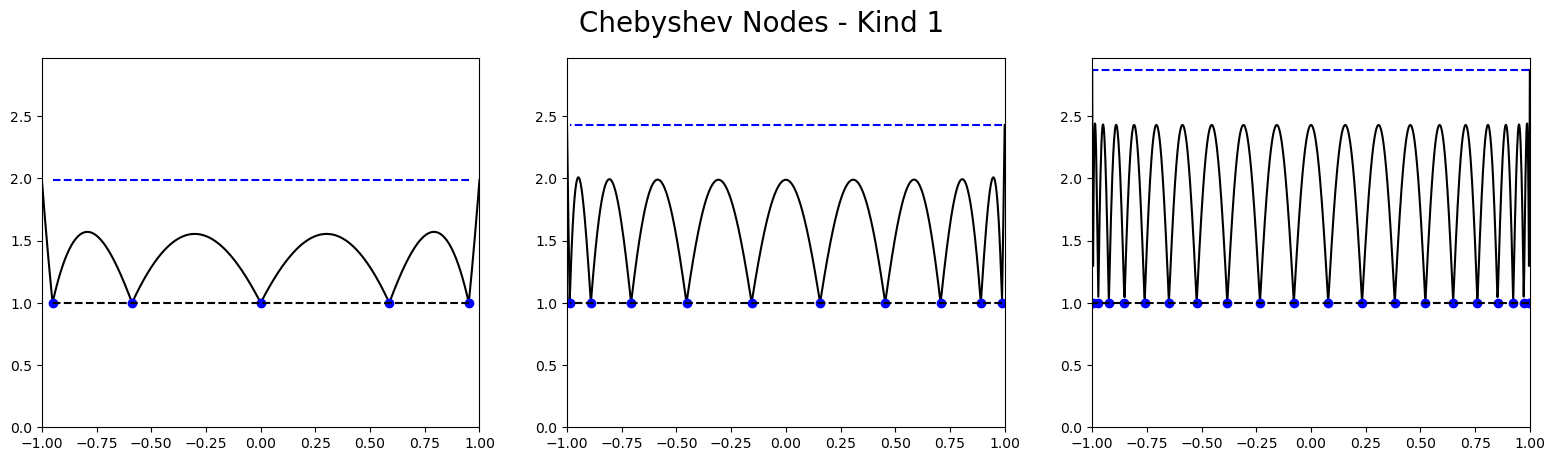

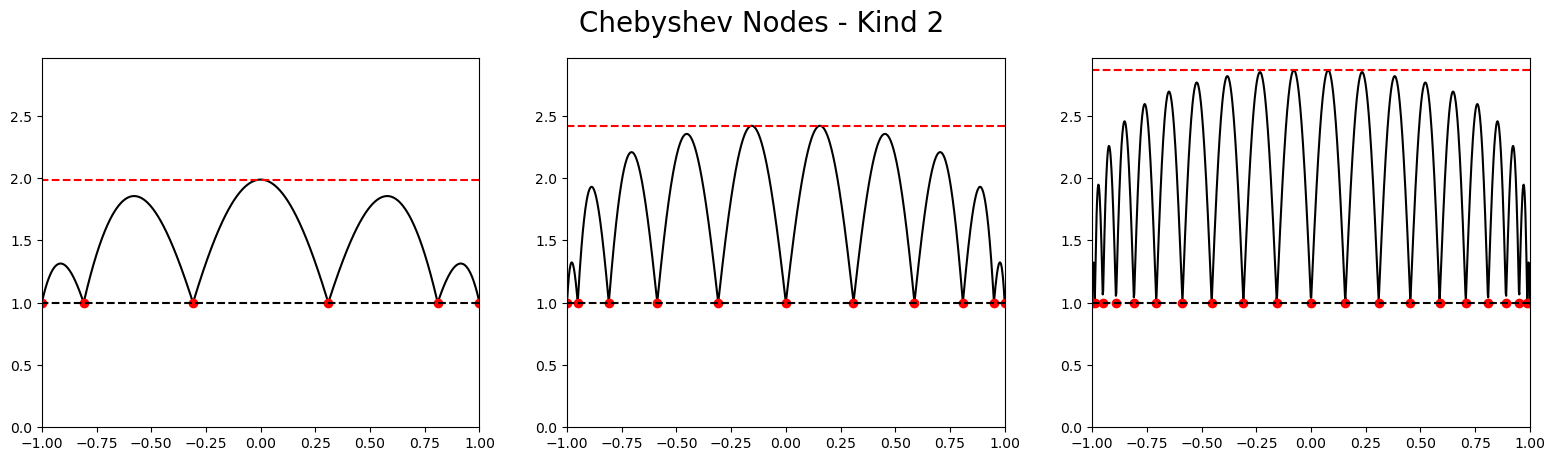

In [195]:
def lebesgue(x, data):
    """Compute the Lebesgue function untuk titik interpolasi tertentu"""
    
    lebesgue = numpy.zeros(x.shape[0])  # inisialisasi array hasil
    for i in range(data.shape[0]):  # loop untuk setiap basis Lagrange
        lagrange_basis = numpy.ones(x.shape[0])  # inisialisasi basis
        for j in range(data.shape[0]):  # loop untuk setiap titik data
            if i != j:
                lagrange_basis *= (x - data[j]) / (data[i] - data[j])  # rumus basis Lagrange
        lebesgue += numpy.abs(lagrange_basis)  # jumlahkan nilai absolut basis
    return lebesgue  # fungsi Lebesgue

N_range = [5, 10, 20]  # jumlah titik interpolasi yang akan diuji
x = numpy.linspace(-1, 1, 1000)  # grid halus untuk evaluasi

# ============================================================
# Equispaced nodes
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 3)
fig.suptitle("Equispaced Points", fontsize="20")  # judul figure
y_max = 0.0
axes = []
for (i, N) in enumerate([5, 10, 20]):  # loop untuk jumlah titik berbeda
    x_hat = -1.0 + 2.0 * numpy.arange(N + 1) / N  # titik equispaced di [-1,1]
    y = lebesgue(x, x_hat)  # hitung fungsi Lebesgue
    axes.append(fig.add_subplot(1, 3, i + 1))  # subplot
    axes[i].semilogy(x, y, 'k')  # plot fungsi Lebesgue (skala log)
    axes[i].semilogy(x_hat, numpy.ones(N + 1), 'ro')  # plot titik data
    axes[i].semilogy(x_hat, numpy.ones(N + 1), 'o--')  # garis bantu
    axes[i].plot(x_hat, numpy.ones(N + 1) * numpy.max(y), 'b--')  # garis batas maksimum
    axes[i].set_xlim((-1, 1))
    y_max = max(y_max, numpy.max(y))  # update nilai maksimum
for i in range(len(N_range)):
    axes[i].set_ylim((0.0, y_max + 0.1))  # set batas sumbu y

# ============================================================
# Chebyshev Nodes - Kind 1
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 3)
fig.suptitle("Chebyshev Nodes - Kind 1", fontsize="20")
y_max = 0.0
axes = []
for (i, N) in enumerate(N_range):
    x_hat = numpy.cos((2.0 * numpy.arange(1, N + 1) - 1.0) / (2.0 * N) * numpy.pi)  # node Chebyshev tipe 1
    y = lebesgue(x, x_hat)
    axes.append(fig.add_subplot(1, 3, i + 1))
    axes[i].plot(x, y, 'k')  # plot fungsi Lebesgue
    axes[i].plot(x_hat, numpy.ones(N), 'bo')  # titik data
    axes[i].plot(x_hat, numpy.ones(N), 'k--')  # garis bantu
    axes[i].plot(x_hat, numpy.ones(N) * numpy.max(y), 'b--')  # garis batas maksimum
    axes[i].set_xlim((-1, 1))
    y_max = max(y_max, numpy.max(y))
for i in range(len(N_range)):
    axes[i].set_ylim((0.0, y_max + 0.1))

# ============================================================
# Chebyshev Nodes - Kind 2 (ekstrem)
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 3)
fig.suptitle("Chebyshev Nodes - Kind 2", fontsize="20")
y_max = 0.0
axes = []
for (i, N) in enumerate(N_range):
    x_hat = numpy.cos(numpy.arange(N + 1) * numpy.pi / N)  # node Chebyshev tipe 2 (ekstrem)
    y = lebesgue(x, x_hat)
    axes.append(fig.add_subplot(1, 3, i + 1))
    axes[i].plot(x, y, 'k')  # plot fungsi Lebesgue
    axes[i].plot(x_hat, numpy.ones(N + 1), 'ro')  # titik data
    axes[i].plot(x_hat, numpy.ones(N + 1), 'k--')  # garis bantu
    axes[i].plot(x_hat, numpy.ones(N + 1) * numpy.max(y), 'r--')  # garis batas maksimum
    axes[i].set_xlim((-1, 1))
    y_max = max(y_max, numpy.max(y))
for i in range(len(N_range)):
    axes[i].set_ylim((0.0, y_max + 0.1))

Untuk benar-benar menunjukkan bahwa node Chebyshev optimal, pertimbangkan polinomial monik $p(z)$ di bidang kompleks dengan derajat $N$
$$
    p(z) = \prod^N_{k=1} (z - z_k)
$$
di mana $z_k$ adalah akar dengan kemungkinan multiplikitas non-trivial. Setelah dimanipulasi sedikit kita juga dapat menuliskan ekspresi terkait
$$\begin{aligned}
    |p(z)| &= \prod^N_{k=1} |z - z_k| \\
    \log|p(z)| &= \sum^N_{k=1} \log|z - z_k|.
\end{aligned}$$

Misalkan
$$
    \phi_N(z) = \frac{1}{N} \sum^N_{k=1} \log |z - z_k|,
$$
Karena $\phi_N(z)$ bersifat *harmonik* maka ia memenuhi persamaan Laplace di bidang kompleks kecuali pada akar $z_k$. Penataan ini dapat dilihat sebagai potensial elektrostatik dengan muatan di akar $z_k$. Potensial dari masing-masing muatan adalah
$$
    \frac{\log |z - z_k|}{N}.
$$

Pertimbangkan sekarang hubungan antara $|p(z)|$ dan $\phi_N(z)$. Dari ekspresi sebelumnya kita tahu bahwa
$$
    |p(z)| = e^{N \phi_N(z)}.
$$

Jika $\phi_N(z)$ kira-kira konstan pada interval $[-1, 1]$ maka $|p(z)|$ juga demikian. Jika di sisi lain $\phi_N(z)$ bervariasi maka variasi $|p(z)|$ akan bersifat eksponensial, terutama untuk $N$ besar! Dengan memandang perilaku ini, pertimbangkan limit $N \rightarrow \infty$ dan pertimbangkan titik-titik $x_j$ yang didistribusikan di $[-1, 1]$ menurut fungsi densitas $\rho(x)$ dengan
$$
    \int^1_{-1} \rho(x) dx = 1.
$$

Dari fungsi densitas ini kita juga tahu jumlah titik kisi dalam interval $[a, b]$ sebagai
$$
    1 = N \int^b_a \rho(x) dx.
$$

Dengan kerangka ini kita dapat menulis potensial sebagai
$$
    \phi(z) = \int^1_{-1} \rho(x) \log |z - x| dx.
$$
Dalam limit $N \rightarrow \infty$ kita dapat menunjukkan untuk titik berjarak sama bahwa
$$
    \phi(z) = -1 +\frac{1}{2} \Re((z + 1) \log(z + 1) - (z-1)\log(z-1)).
$$
Perhatikan bahwa $\phi(0) = -1$ dan $\phi(\pm 1) = -1 + \log 2$ yang menyiratkan bahwa jika sebuah polinomial $p$ memiliki akar berjarak sama pada $[-1, 1]$ maka nilainya akan menjadi $2^N$ kali lebih besar di sekitar titik $\pm 1$ daripada di sekitar $0$.

Sebaliknya, jika kita mempertimbangkan distribusi untuk titik Chebyshev
$$
    \rho(x) = \frac{1}{\pi \sqrt{1 - x^2}}, \quad x\in[-1,1]
$$
 kita dapat menunjukkan bahwa potensial yang dihasilkan adalah
$$
    \phi(z) = \log\frac{\left|z - \sqrt{z^2 - 1} \right |}{2}.
$$

Menariknya rumus-rumus ini memiliki interpretasi sederhana: kurva level $\phi(z)$ adalah elips dengan fokus $\pm 1$. Nilai $\phi(z)$ sepanjang elips semacam itu adalah logaritma dari setengah jumlah sumbu semi-mayor dan semi-minor elips. Elips degenerate $[-1, 1]$ juga merupakan kurva level dan mengambil nilai konstan $-\log 2$. Ini ternyata optimal dengan polinomial tumbuh sebagai
$$
    |p(z)| = e^{N \phi(x)} \approx 2^{-N}, ~~~ x\in[-1,1].
$$

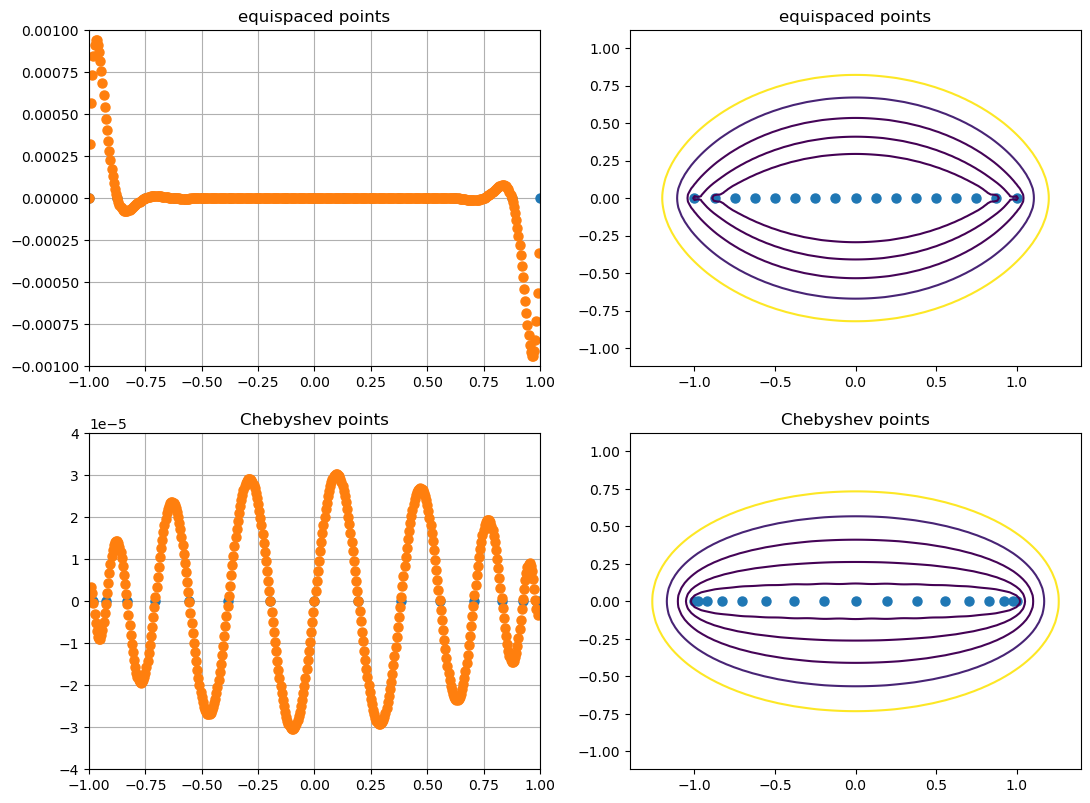

In [196]:
# Adapted from program 10 in Trefethen - "Spectral Methods for MATLAB"
N = 16  # jumlah titik interpolasi

fig, axes = plt.subplots(2, 2)  # membuat figure dengan 2x2 subplot
fig.set_figwidth(fig.get_figwidth() * 2)  # memperlebar figure
fig.set_figheight(fig.get_figheight() * 2)  # mempertinggi figure

# loop untuk dua jenis distribusi titik: equispaced dan Chebyshev
for (i, point_distribution) in enumerate(("equispaced points", "Chebyshev points")):
    if i == 0:
        x = -1.0 + 2.0 * numpy.arange(N + 1) / N  # titik equispaced di [-1,1]
    else:
        x = numpy.cos(numpy.pi * numpy.arange(N+1) / N)  # titik Chebyshev (ekstrem polinomial)

    # Bangun polinomial dengan akar di titik x
    p = numpy.poly(x)  # polinomial dengan akar di x

    # Plot p(x) di interval [-1,1]
    x_fine = numpy.arange(-1, 1, .005)  # grid halus
    axes[i, 0].plot(x, 0*x, '.', markersize=13)  # plot akar (nilai nol)
    axes[i, 0].plot(x_fine, numpy.polyval(p, x_fine), '.', markersize=13)  # plot nilai polinomial
    axes[i, 0].grid(True)
    axes[i, 0].set_title(point_distribution)  # judul subplot
    axes[i, 0].set_xlim((-1, 1))
    if i == 0:
        axes[i, 0].set_ylim((-1e-3, 1e-3))  # skala y untuk equispaced
    else:
        axes[i, 0].set_ylim((-4e-5, 4e-5))  # skala y untuk Chebyshev

    # Plot kurva equipotensial (kontur nilai polinomial di bidang kompleks)
    axes[i, 1].plot(x.real, x.imag, '.', markersize=13)  # plot akar di bidang kompleks
    axes[i, 1].set_xlim((-1.4, 1.4))
    axes[i, 1].set_ylim((-1.12, 1.12))
    X, Y = numpy.meshgrid(numpy.arange(-1.4, 1.4, 0.02), 
                          numpy.arange(-1.12, 1.12, 0.02))  # grid 2D
    levels = 10**(numpy.arange(-4.0, 1.0))  # level kontur (skala log)
    axes[i, 1].contour(X, Y, numpy.abs(numpy.polyval(p, X + 1j * Y)), levels)  # plot kontur nilai polinomial
    axes[i, 1].set_title(point_distribution)  # judul subplot

### Diferensiasi Chebyshev

Salah satu cara kita dapat menurunkan beda hingga adalah dengan menginterpolasi sebuah polinomial melalui titik-titik stencil dan mengambil turunan interpolan yang dihasilkan. Kita dapat melakukan hal yang sama untuk menemukan matriks diferensiasi Chebyshev. Karena interpolan mana pun unik berdasarkan titik-titik yang dilaluinya, kita hanya perlu menentukan turunan berdasarkan node Chebyshev itu sendiri.

Misalkan
$$
   p_N(x_j) = v_j, \quad 0 \leq j \leq N 
$$
adalah polinomial derajat $N$, maka turunan yang dihasilkan adalah
$$
    p'_N(x_j) = w_j.
$$

Karena operasi ini linear, kita dapat membentuknya sebagai perkalian dengan matriks:
$$
    \mathbf{w} = \mathbf{D}_N \mathbf{v}
$$

Sebagai contoh, pertimbangkan kasus ketika $N=1$, maka titik interpolasi adalah $x_0 = 1$ dan $x_1 = -1$ yang menghasilkan
$$
    p_1(x) = \frac{1}{2} (1  + x)v_0 + \frac{1}{2}(1 - x)v_1
$$
yang untuk itu
$$
    p'_1(x) = \frac{1}{2}(v_0 - v_1).
$$
Matriks diferensiasi yang dihasilkan kemudian adalah
$$
    D_1 = \begin{bmatrix}
        1/2 & -1/2 \\
        1/2 & -1/2
    \end{bmatrix}.
$$

Untuk kasus $N=2$ kita memiliki titik $x_0 = 1$, $x_1 = 0$, dan $x_2 = -1$ dengan interpolan kuadratik
$$
    p_2(x) = \frac{1}{2} x ( 1 + x) v_0 + (1+x)(1-x)v_1 + \frac{1}{2} x (x-1) v_2
$$
yang menghasilkan turunan
$$
    p'_2(x) = (x+ 1/2) v_0 - 2 x v_1 + (x-1/2)v_2
$$
dan matriks diferensiasi
$$
    D_2 = \begin{bmatrix}
        3/2  & -2 & 1/2 \\
        1/2  &  0 & -1/2 \\
        -1/2 &  2 & -3/2
    \end{bmatrix}.
$$

Perhatikan bahwa untuk kedua kasus ini formula-formula ini mengambil bentuk yang familier, namun matriks diferensiasi mereka memiliki sifat satu sisi tambahan. Untuk aproksimasi orde tinggi, hal ini menyimpang dari metode beda hingga biasa karena jarak titik yang tidak merata. Secara umum matriks diferensiasi Chebyshev mengambil bentuk
$$\begin{aligned}
    (D_N)_{00} = \frac{2 N^2 + 1}{6}, & & (D_N)_{NN} = -\frac{2N^2 + 1}{6}, \\
    (D_N)_{jj} = \frac{-x_j}{2(1 - x_j^2)}, & & j=1,\ldots,N-1 \\
    (D_N)_{ij} = \frac{c_i(-1)^{i+j}}{c_j (x_i - x_j)}, & & i\neq j, ~~ i,j = 0, \ldots, N
\end{aligned}$$
di mana
$$
    c_i = \left \{ \begin{aligned}
        2, & & i=0 \text{ or } N \\
        1, & & \text{lainnya}.
    \end{aligned} \right .
$$

In [197]:
# Based on Trefethen cheb function and
# the post at http://www.scientificpython.net/pyblog/pseudospectral-differentiation
import operator  # modul untuk operasi dasar (misalnya perkalian)
import scipy  # pustaka komputasi ilmiah
from functools import reduce  # fungsi reduce untuk operasi berulang (misalnya perkalian elemen)

def cheb(N):
    # Hitung titik Chebyshev (ekstrem polinomial Chebyshev)
    x = numpy.cos(numpy.pi * numpy.arange(N+1) / N)  # titik Chebyshev di [-1,1]

    e = numpy.ones((N + 1, 1))  # vektor kolom berisi 1
    Xdiff = numpy.outer(x, e) - numpy.outer(e, x) + numpy.identity(N + 1)  
    # matriks perbedaan (x_i - x_j), ditambah identitas untuk menghindari pembagian nol

    xprod = -reduce(operator.mul, Xdiff)  # hasil kali setiap baris (produk perbedaan)
    W = numpy.outer(1.0 / xprod, e)  # bobot untuk basis Lagrange

    D = W / numpy.multiply(W.T, Xdiff)  # matriks diferensiasi Chebyshev (off-diagonal)
    d = 1 - sum(D)  # nilai diagonal (penyesuaian agar jumlah baris = 0)

    for k in range(0, N+1):  # set elemen diagonal
        D[k, k] = d[k]

    return -D.T, x  # kembalikan matriks diferensiasi (transpose negatif) dan titik Chebyshev

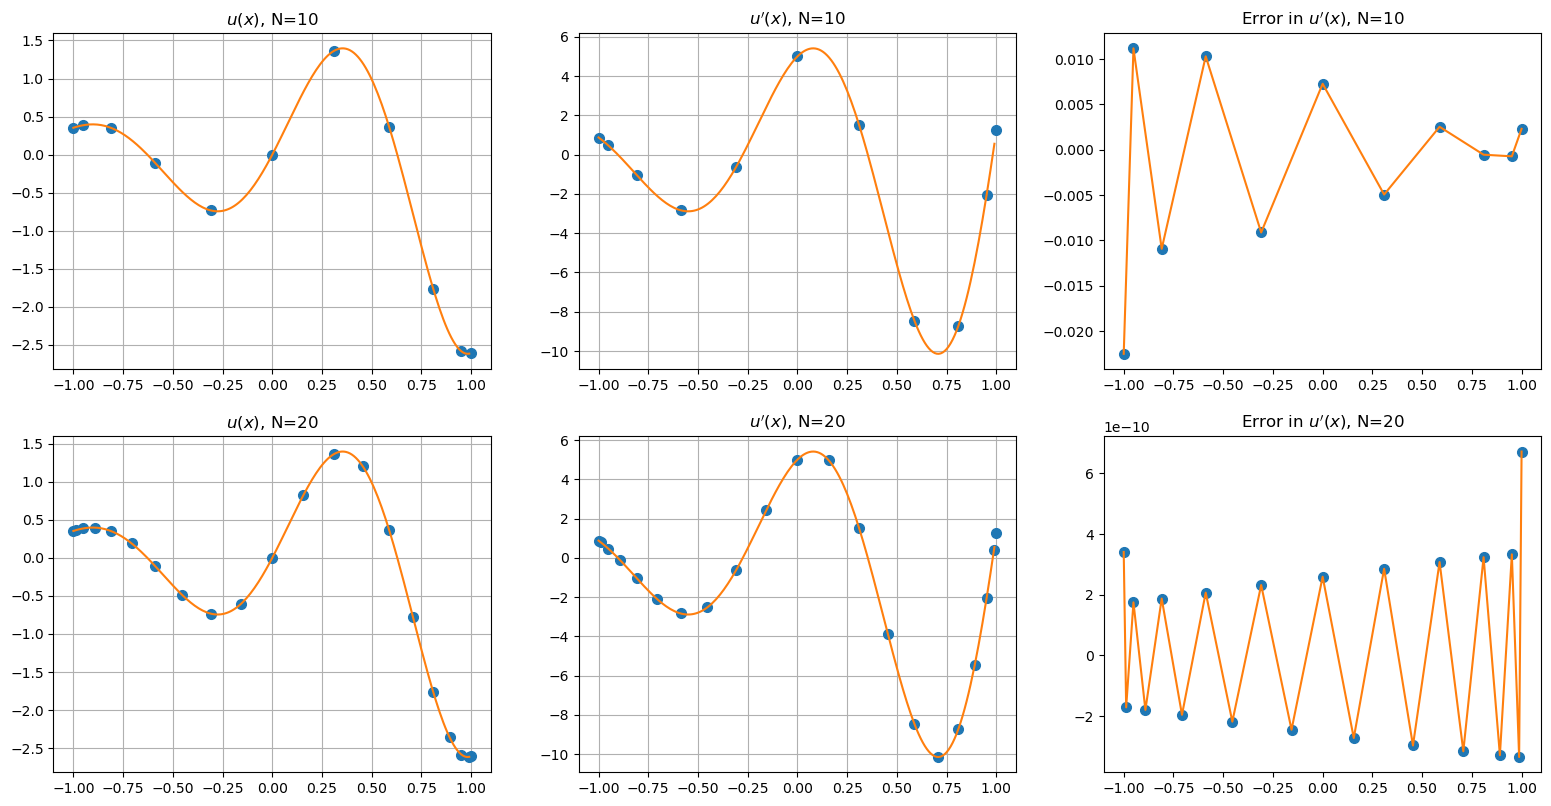

In [198]:
# Test out some differentiation on a smooth function
u = lambda x: numpy.exp(x) * numpy.sin(5.0 * x)  
# fungsi u(x) = e^x * sin(5x)

u_prime = lambda x: numpy.exp(x) * (numpy.sin(5.0 * x) + 5.0 * numpy.cos(5.0 * x))  
# turunan analitik u'(x) = e^x [sin(5x) + 5cos(5x)]

x_fine = numpy.arange(-1, 1, 0.01)  # grid halus untuk evaluasi fungsi
fig, axes = plt.subplots(2, 3)  # membuat figure dengan 2x3 subplot
fig.set_figwidth(fig.get_figwidth() * 3)  # memperlebar figure
fig.set_figheight(fig.get_figheight() * 2)  # mempertinggi figure

for (i, N) in enumerate((10, 20)):  # loop untuk dua jumlah titik Chebyshev (N=10 dan N=20)
    D, x = cheb(N)  # dapatkan matriks diferensiasi Chebyshev dan titik grid

    # Plot fungsi u(x)
    axes[i, 0].plot(x, u(x), '.', markersize=14)  # nilai u(x) di titik Chebyshev
    axes[i, 0].grid(True)
    axes[i, 0].plot(x_fine, u(x_fine))  # kurva halus u(x)
    axes[i, 0].set_title('$u(x)$, N=%s' % N)

    # Plot turunan u'(x)
    axes[i, 1].plot(x, numpy.dot(D, u(x)), '.', markersize=14)  # turunan numerik via matriks Chebyshev
    axes[i, 1].grid(True)
    axes[i, 1].plot(x_fine, u_prime(x_fine))  # turunan analitik
    axes[i, 1].set_title("$u'(x)$, N=%s" % N)

    # Plot error antara turunan numerik dan analitik
    error = numpy.dot(D, u(x)) - u_prime(x)  # selisih
    axes[i, 2].plot(x, error, '.', markersize=14)  # error di titik Chebyshev
    axes[i, 2].plot(x, error)  # garis error
    axes[i, 2].set_title("Error in $u'(x)$, N=%s" % N)

plt.show()  # tampilkan semua plot

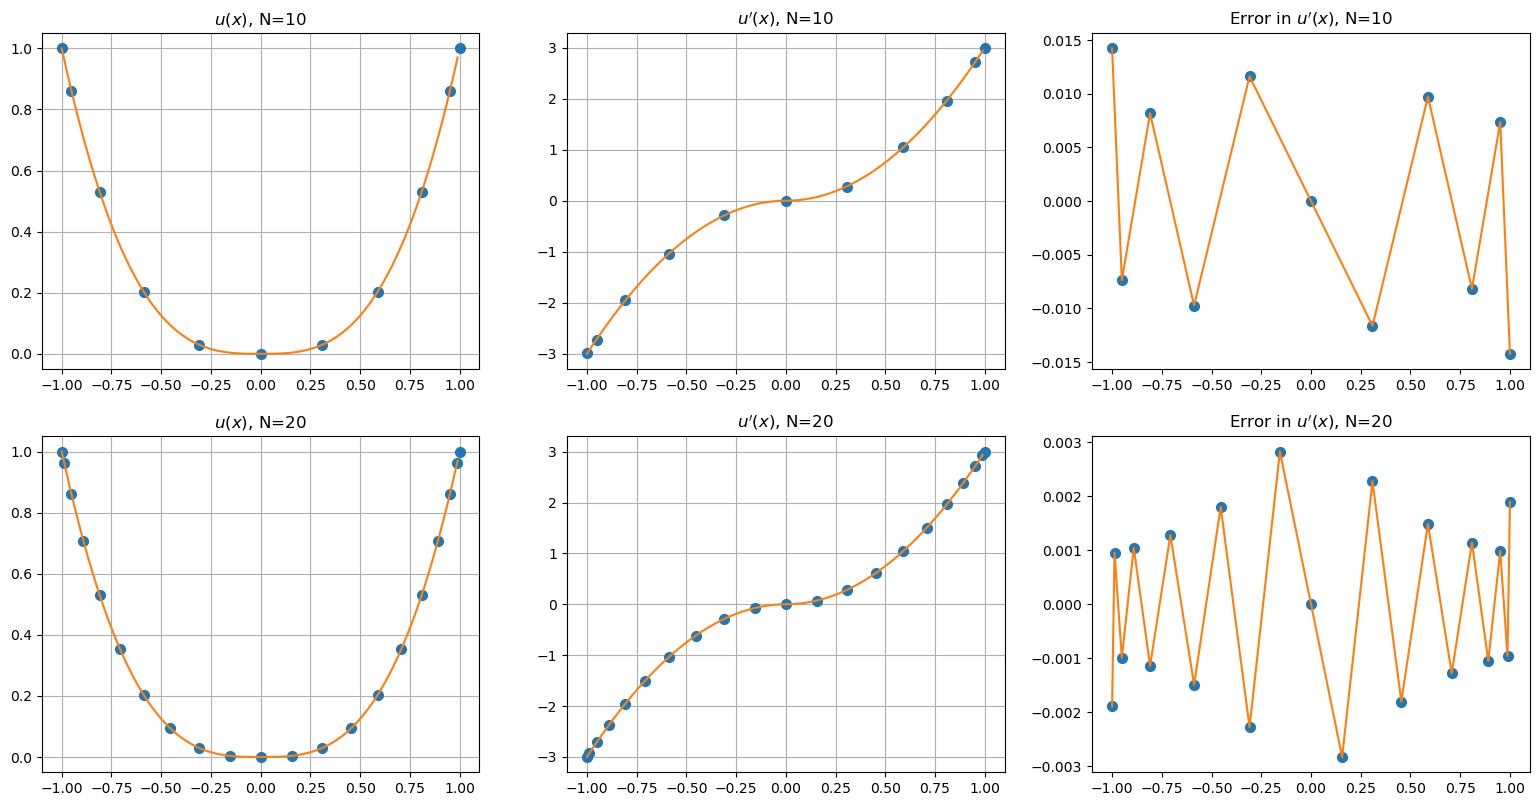

In [199]:
# Bounded Variation in 3rd derivative
u = lambda x: numpy.abs(x)**3  
# fungsi u(x) = |x|^3, halus tetapi memiliki variasi terbatas pada turunan ketiga

u_prime = lambda x: 3.0 * x * numpy.abs(x)  
# turunan analitik u'(x) = 3x|x|

x_fine = numpy.arange(-1, 1, 0.01)  # grid halus untuk evaluasi fungsi
fig, axes = plt.subplots(2, 3)  # membuat figure dengan 2x3 subplot
fig.set_figwidth(fig.get_figwidth() * 3)  # memperlebar figure
fig.set_figheight(fig.get_figheight() * 2)  # mempertinggi figure

for (i, N) in enumerate((10, 20)):  # loop untuk dua jumlah titik Chebyshev (N=10 dan N=20)
    D, x = cheb(N)  # dapatkan matriks diferensiasi Chebyshev dan titik grid

    # Plot fungsi u(x)
    axes[i, 0].plot(x, u(x), '.', markersize=14)  # nilai u(x) di titik Chebyshev
    axes[i, 0].grid(True)
    axes[i, 0].plot(x_fine, u(x_fine))  # kurva halus u(x)
    axes[i, 0].set_title('$u(x)$, N=%s' % N)

    # Plot turunan u'(x)
    axes[i, 1].plot(x, numpy.dot(D, u(x)), '.', markersize=14)  # turunan numerik via matriks Chebyshev
    axes[i, 1].grid(True)
    axes[i, 1].plot(x_fine, u_prime(x_fine))  # turunan analitik
    axes[i, 1].set_title("$u'(x)$, N=%s" % N)

    # Plot error antara turunan numerik dan analitik
    error = numpy.dot(D, u(x)) - u_prime(x)  # selisih
    axes[i, 2].plot(x, error, '.', markersize=14)  # error di titik Chebyshev
    axes[i, 2].plot(x, error)  # garis error
    axes[i, 2].set_title("Error in $u'(x)$, N=%s" % N)

plt.show()  # tampilkan semua plot

<>:33: SyntaxWarning: invalid escape sequence '\e'
<>:33: SyntaxWarning: invalid escape sequence '\e'
C:\Users\WIND11\AppData\Local\Temp\ipykernel_38304\2339864507.py:33: SyntaxWarning: invalid escape sequence '\e'
  titles = ['$|x^3|$', '$\exp(-x^{-2})$', '$1 / (1 + x^2)$', '$x^10$']


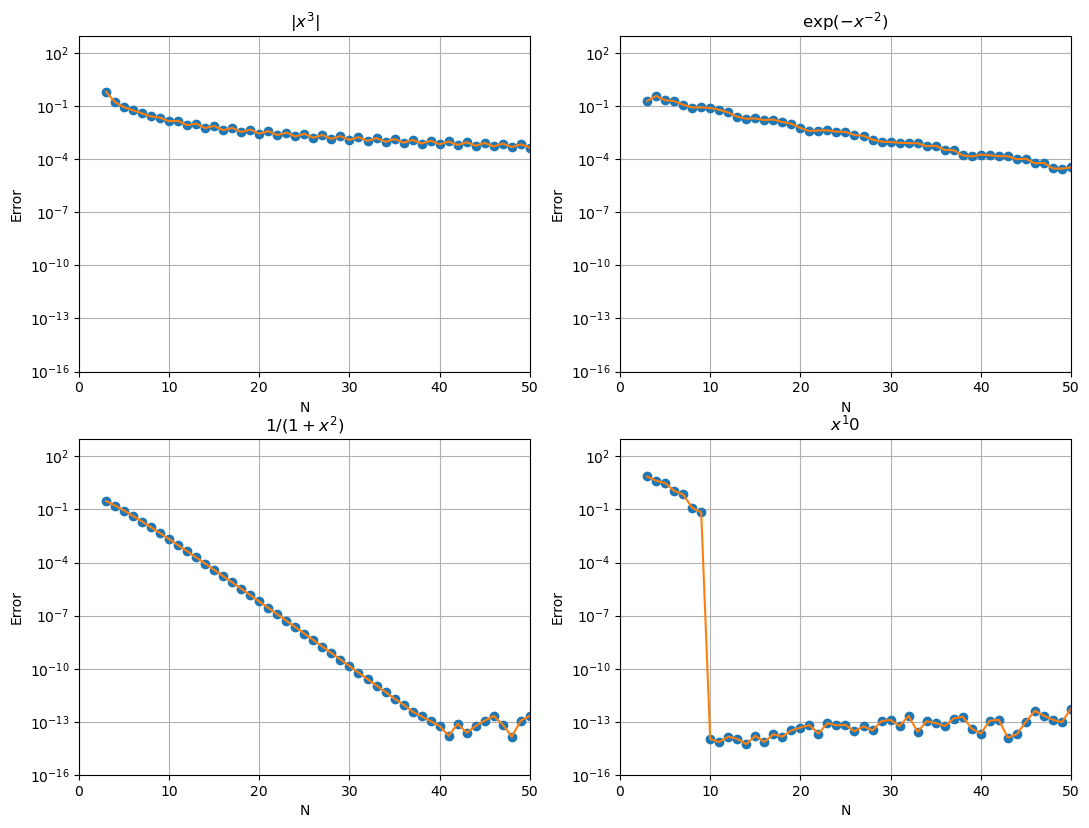

In [200]:
# Compare errors more carefully (program 12 in Trefethen)
N_max = 50  # jumlah maksimum titik Chebyshev
error = numpy.zeros((4, N_max - 2))  # array untuk menyimpan error dari 4 fungsi uji
N_range = numpy.arange(3, N_max + 1)  # rentang N dari 3 sampai 50

for (i, N) in enumerate(N_range):
    D, x = cheb(N)  # matriks diferensiasi Chebyshev dan titik grid

    # 1. Fungsi dengan turunan ketiga terbatas (bounded variation)
    v = numpy.abs(x)**3
    v_prime = numpy.abs(x) * x * 3.0
    error[0, i] = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.inf)  # error maksimum

    # 2. Fungsi C∞ (halus, tetapi tidak analitik di 0)
    v = numpy.exp(-x**(-2))
    v_prime = 2 * v / x**3
    error[1, i] = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.inf)

    # 3. Fungsi analitik di [-1,1]
    v = 1.0 / (1.0 + x**2)
    v_prime = -2.0 * x * v**2
    error[2, i] = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.inf)

    # 4. Polinomial sederhana
    v = x**10
    v_prime = 10 * x**9
    error[3, i] = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.inf)

# Plot errors
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
titles = ['$|x^3|$', '$\exp(-x^{-2})$', '$1 / (1 + x^2)$', '$x^10$']

for (i, title) in enumerate(titles):
    axes = fig.add_subplot(2, 2, i + 1)
    axes.semilogy(N_range, error[i, :], '.', markersize=12)  # plot error (titik)
    axes.semilogy(N_range, error[i, :])  # plot error (garis)
    axes.set_xlim((0, N_max))
    axes.set_ylim((1e-16, 1e3))  # skala log error
    axes.grid(True)
    axes.set_xlabel("N")  # jumlah titik Chebyshev
    axes.set_ylabel("Error")
    axes.set_title(title)  # judul subplot sesuai fungsi

Sebagai aplikasi lain dari matriks diferensiasi Chebyshev, kita juga dapat menggunakannya untuk menghitung solusi masalah Poisson dengan kondisi batas non-periodik. Pertimbangkan masalah
$$
    u_{xx} = e^{4x},\quad \Omega = [-1, 1], \quad u(\pm 1) = 0
$$
yang memiliki solusi
$$
    u(x) = \frac{e^{4x} - x \sinh(4) - \cosh(4)}{16}.
$$
Berasal dari sebelumnya kita kemudian memiliki
$$
    D^2_N U = F
$$
yang kemudian dapat dibalik untuk menemukan solusi.

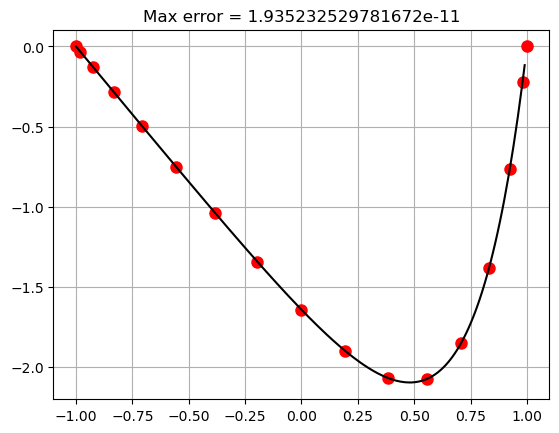

In [201]:
# Adapted from Trefethen program 13
f = lambda x: numpy.exp(4.0 * x)  
# fungsi sumber f(x) = e^(4x)

u_true = lambda x: (numpy.exp(4.0 * x) - x * numpy.sinh(4.0) - numpy.cosh(4.0)) / 16.0  
# solusi analitik dari masalah Poisson dengan kondisi batas u(-1)=u(1)=0

N = 16  # jumlah titik Chebyshev
x_fine = numpy.arange(-1, 1, 0.01)  # grid halus untuk evaluasi solusi analitik

# Hitung matriks diferensiasi Chebyshev dan buang titik batas
D, x = cheb(N)  # matriks diferensiasi dan titik Chebyshev
D2 = numpy.dot(D, D)[1:-1, 1:-1]  # matriks turunan kedua, hanya untuk titik interior (buang boundary)

# Selesaikan masalah Poisson
U = numpy.zeros(N + 1)  # inisialisasi solusi
U[1:-1] = numpy.linalg.solve(D2, f(x[1:-1]))  # pecahkan sistem linear untuk titik interior
error = numpy.linalg.norm(U - u_true(x), ord=numpy.inf)  # error maksimum (norma tak hingga)

# Plot hasil
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x, U, 'r.', markersize=16)  # solusi numerik di titik Chebyshev
axes.plot(x_fine, u_true(x_fine), 'k')  # solusi analitik halus
axes.grid(True)
axes.set_title("Max error = %s" % error)  # tampilkan error maksimum
plt.show()

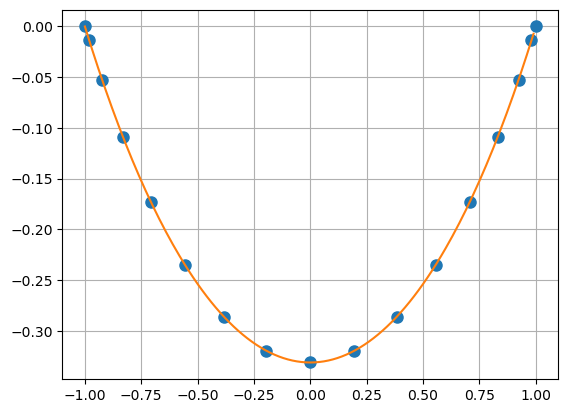

In [202]:
# Adapted from Trefethen program 14 - Non-linear Elliptic
f = lambda u: numpy.exp(u)  
# fungsi non-linear f(u) = e^u

N = 16  # jumlah titik Chebyshev
x_fine = numpy.arange(-1, 1, 0.01)  # grid halus untuk interpolasi hasil

# Hitung matriks diferensiasi Chebyshev dan buang titik batas
D, x = cheb(N)  # matriks diferensiasi dan titik Chebyshev
D2 = numpy.dot(D, D)[1:-1, 1:-1]  # matriks turunan kedua, hanya untuk titik interior (boundary dihapus)

# Selesaikan masalah menggunakan iterasi titik tetap (fixed-point iteration)
U = numpy.zeros(N + 1)  # inisialisasi solusi
U_new = numpy.zeros(N + 1)  # inisialisasi solusi baru
delta = 1.0  # selisih awal antar iterasi
step = 0  # counter jumlah iterasi
while delta > 1e-15:  # berhenti jika konvergen (error sangat kecil)
    U_new[1:-1] = numpy.linalg.solve(D2, f(U[1:-1]))  # pecahkan sistem linear untuk titik interior
    delta = numpy.linalg.norm(U_new - U, ord=numpy.inf)  # hitung error maksimum antar iterasi
    U = U_new  # update solusi
    step += 1  # tambah counter iterasi

# Plot hasil
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x, U, '.', markersize=16)  # solusi numerik di titik Chebyshev
U_interp = numpy.polyval(numpy.polyfit(x, U, N), x_fine)  # interpolasi polinomial untuk kurva halus
axes.plot(x_fine, U_interp, '-')  # plot solusi interpolasi
axes.grid(True)
plt.show()

Kita juga dapat melakukan masalah berdimensi lebih tinggi. Pertimbangkan PDE
$$
    u_{xx} + u_{yy} = 10 \sin(8 x (y - 1)), \quad -1 < x,~y < 1
$$
dengan $u = 0$ pada batas. Kita dapat terus menggunakan matriks diferensiasi yang kita gunakan sebelumnya. Jika kita mengurutkan tak dikenal dalam urutan alami seperti sebelumnya kita dapat kembali menggunakan produk Kronecker untuk membangun matriks yang relevan.

Misalnya, jika kita mempertimbangkan kasus $N=4$ kita memiliki matriks diferensiasi satu dimensi
$$
    D^2_4 = \begin{bmatrix}
        -14 & 6 & -2 \\
        4 & -6 & 4 \\
        -2 & 6 & -14
    \end{bmatrix}
$$
yang dapat mengaproksimasi matriks dimensi x dengan urutan yang ditentukan sebagai `kron(I, D2)` yang menghasilkan
$$
    I \otimes D^2_N = \begin{bmatrix}
        -14 & 6 & -2 \\
        4 & -6 & 4 \\
        -2 & 6 & -14 \\
        & & & -14 & 6 & -2 \\
        & & & 4 & -6 & 4 \\
        & & & -2 & 6 & -14 \\
        & & & & & & -14 & 6 & -2 \\
        & & & & & & 4 & -6 & 4 \\
        & & & & & & -2 & 6 & -14
    \end{bmatrix}.
$$

Turunan dalam arah y akan menjadi `kron(D2, I)` menghasilkan
$$
    I \otimes D^2_N = \begin{bmatrix}
        -14 &     &     &   6 &     &     &  -2 &     &     \\
            & -14 &     &     &   6 &     &     &  -2 &     \\
            &     & -14 &     &     &   6 &     &     &  -2 \\
          4 &     &     &  -6 &     &     &   4 &     &     \\
            &   4 &     &     &  -6 &     &     &   4 &     \\
            &     &   4 &     &     &  -6 &     &     &   4 \\
         -2 &     &     &   6 &     &     & -14 &     &     \\
            &  -2 &     &     &   6 &     &     & -14 &     \\
            &     &  -2 &     &     &   6 &     &     & -14 \\
    \end{bmatrix}.
$$

Semua bersama kita dapat memperoleh operator Laplacian terdiskret dengan menambahkan kedua matriks di atas dengan
$$
    L_N = I \otimes D^2_N + D^2_N \otimes I.
$$

Kekurangan menggunakan matriks ini dibandingkan beda hingga adalah bahwa matriksnya tidak selangka. Untungnya, jika kita dapat memanfaatkan konvergensi spektral dari metode ini, kita akan dapat menggunakan jauh lebih sedikit titik untuk menyelesaikan sistem.

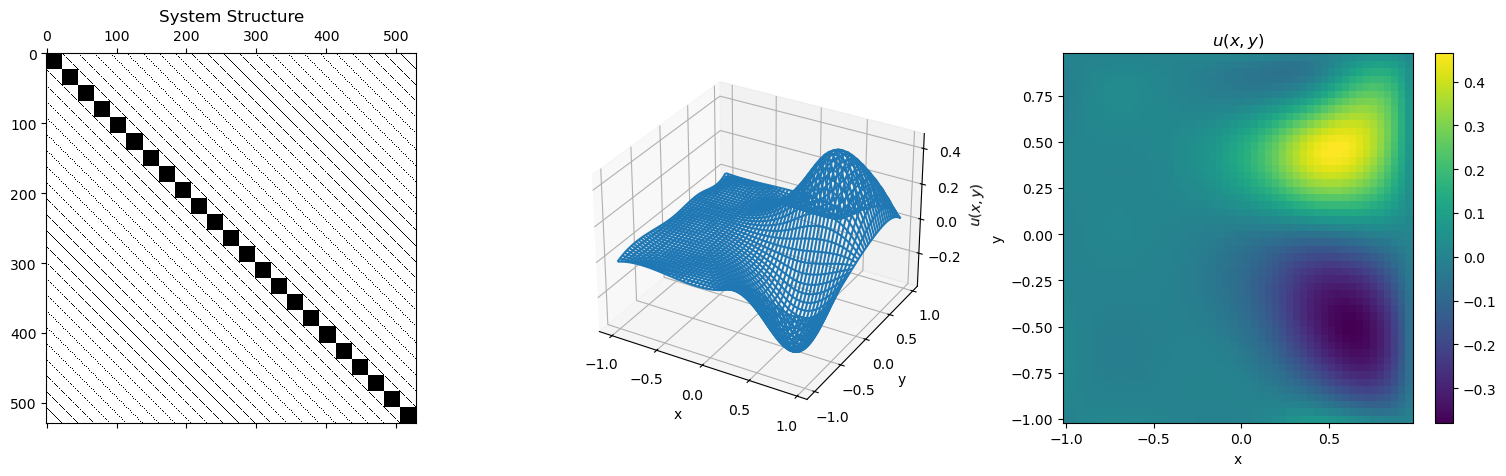

In [203]:
# Based on Trefethen program 16
import mpl_toolkits.mplot3d  # modul untuk plotting 3D
import scipy.interpolate  # modul untuk interpolasi 2D/3D

f = lambda x, y: 10.0 * numpy.sin(8.0 * x * (y - 1.0))  
# fungsi sumber f(x,y) untuk persamaan Poisson 2D

N = 24  # jumlah titik Chebyshev
D, x = cheb(N)  # matriks diferensiasi Chebyshev dan titik grid
X, Y = numpy.meshgrid(x[1:-1], x[1:-1])  # grid interior (buang boundary)
X = X.flatten()  # ubah ke vektor
Y = Y.flatten()

D2 = numpy.dot(D, D)  # matriks turunan kedua
D2 = D2[1:-1, 1:-1]  # hanya interior
I = numpy.eye(N - 1)  # matriks identitas
L = numpy.kron(I, D2) + numpy.kron(D2, I)  
# operator Laplace 2D dengan produk Kronecker

# Selesaikan sistem linear
U = numpy.linalg.solve(L, f(X, Y))  # solusi numerik di grid interior

# Plot struktur sistem dan hasil
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 3)

axes = fig.add_subplot(1, 3, 1)
axes.spy(L)  # visualisasi struktur matriks sparse
axes.set_title("System Structure")

u = numpy.zeros((N + 1, N + 1))  # inisialisasi solusi penuh
u[1:-1, 1:-1] = U.reshape(N - 1, N - 1)  # masukkan solusi interior
X, Y = numpy.meshgrid(x, x)  # grid penuh
x_fine = numpy.arange(-1, 1, 0.04)  # grid halus untuk interpolasi
X_fine, Y_fine = numpy.meshgrid(x_fine, x_fine)
u_interpolant = scipy.interpolate.bisplrep(X, Y, u, s=1)  # interpolasi spline 2D
u_fine = scipy.interpolate.bisplev(x_fine, x_fine, u_interpolant)  # evaluasi interpolasi

axes = fig.add_subplot(1, 3, 2, projection='3d')
axes.plot_wireframe(X_fine, Y_fine, u_fine)  # plot wireframe 3D
axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_zlabel('$u(x,y)$')

axes = fig.add_subplot(1, 3, 3)
plot = axes.pcolor(X_fine, Y_fine, u_fine)  # plot kontur warna 2D
axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_title('$u(x,y)$')
fig.colorbar(plot)  # tambahkan colorbar

plt.show()

## FFT dan Chebyshev

FFT adalah alat yang kuat yang membuat metode spektral begitu menarik tetapi kita baru saja melihat bagaimana ia dapat digunakan pada deret Fourier. Ternyata satu set ekuivalensi akan memungkinkan kita untuk menggunakan FFT pada deret Chebyshev juga.

![Relationships between x, z, and \theta (from Trefethen fig 8.1)](./images/relationships.png)

Misalkan $z \in \mathbb C$ sedemikian sehingga $|z| = 1$, biarkan $\theta$ menjadi argumen $z$, yaitu $z = e^{i \theta}$ (perhatikan bahwa $\theta$ hanya unik sampai kelipatan $2 \pi$), dan $x$ menjadi bagian real dari $z$ sehingga $x = \Re z = \cos \theta$. Untuk semua $x \in [-1, 1]$ terdapat dua nilai $z$ yang sesuai dengan naik dan turun ke $z$ pada lingkaran satuan, yaitu
$$
    x = \Re z = \frac{1}{2} (z + z^{-1}) = \cos \theta.
$$

Sekarang pertimbangkan polinomial Chebyshev $T_n(x)$ yang untuk polinomial ke-$n+1$ adalah
$$
    T_{n+1}(x) = \frac{1}{2} (z^{n+1} + z^{-n-1}) = \frac{1}{2} (z^n + z^{-n}) - \frac{1}{2}(z^{n-1} + z^{1-n})
$$
yang juga sesuai dengan relasi rekursif untuk polinomial Chebyshev
$$
    T_{n+1}(x) = 2 x T_n(x) - T_{n-1}(x).
$$
Perhatikan bahwa kita sebenarnya menggunakan hubungan antara $x$ dan $z$ yang kita miliki dari hubungan lingkaran satuan.

Karena kita juga tahu bahwa $T_n(x)$ adalah polinomial derajat $n$, kita dapat menggunakan polinomial Chebyshev sebagai basis
$$
    p(x) = \sum^\infty_{n=0} a_n T_n(x), \quad x \in [-1, 1].
$$
Ini juga sesuai dengan polinomial Laurent derajat $N$ dalam $z$ dan $z^{-1}$ sedemikian rupa sehingga $z^n$ dan $z^{-n}$ memiliki koefisien yang sama
$$
    \tilde{p}(z) = \frac{1}{2} \sum^\infty_{n=0} a_n (z^n + z^{-n}), \quad |z| = 1,
$$
yang juga dikenal sebagai self-reciprocal. Ada juga polinomial lain dalam $\theta$ yang $2 \pi$ periodik sehingga
$$
    P(\theta) = \sum^\infty_{n=0} a_n \cos n \theta, \quad \theta \in \mathbb R.
$$

Jadi ke mana ini membawa kita? Kita tahu bahwa polinomial-polinomial ini setara jika kita mempunyai hubungan yang awalnya kita definisikan antara variabel independen $x$, $z$, dan $\theta$. Mari sekarang pertimbangkan bagaimana polinomial-polinomial ini akan berperan sebagai interpolan.

Misalkan $f(x)$ adalah fungsi sembarang pada $[-1, 1]$, kita kemudian dapat membentuk fungsi self-reciprocal $\tilde{f~}(z)$ dengan
$$
    \tilde{f~}(z) = f\left(\frac{1}{2} (z + z^{-1})\right)
$$
dan selanjutnya
$$
    F(\theta) = f(\cos \theta).
$$

Sekarang mari kita lihat bagaimana versi terpotong dari polinomial kita menginterpolasi fungsi-fungsi ini. Interpolan akan memiliki titik nodal pada
$$
    \theta_j = j \pi / N, \quad z_j = e^{i\theta_j}, \quad \text{dan}  \quad x_j = \cos \theta_j = \Re z_j.
$$
Dengan ini kita dapat membuat pernyataan berikut mengenai polinomial terpotong ini untuk sebuah fungsi $f(z)$:
 - $P(\theta)$ menginterpolasi $F(\theta)$ (dengan asumsi bahwa ia genap dan $2 \pi$-periodik) pada titik-titik berjarak sama $\theta_j$,
 - $\tilde{p~}(z)$ menginterpolasi $\tilde{f~}(z)$ pada akar kesatuan $z_j$,
 - $p(x)$ menginterpolasi $f(x)$ pada titik-titik Chebyshev $x_j$.


Kita sekarang mulai melihat bagaimana kita mungkin dapat menggunakan FFT dengan deret Chebyshev karena ekuivalensi ini. Proses dasarnya adalah sebagai berikut:
1. Diberikan $f$ sembarang, cari interpolan polinomial trigonometri $Q$ dari $F$,
2. Diferensiasikan interpolan ini di ruang Fourier, dan
3. Transformasikan kembali ke domain asli pada $x \in [-1, 1]$.


In [204]:
# Based on Trefethen chebfft function
def chebfft(v):
    N = v.shape[0] - 1  # jumlah titik Chebyshev (N+1 panjang vektor)
    if N == 0:
        return 0  # kasus trivial jika hanya satu titik
    
    x = numpy.cos(numpy.arange(N+1) * numpy.pi / N)  
    # titik Chebyshev di [-1,1]

    ii = numpy.arange(N)  # indeks wave number
    
    # Transformasi dari x ke θ (simetri untuk FFT)
    V = numpy.hstack((v, v[N-1:0:-1]))  # extend vektor dengan simetri
    U = fft.fft(V).real  # FFT dari vektor simetri
    wave_numbers = numpy.hstack((ii, [0], numpy.arange(1-N, 0)))  
    # bilangan gelombang untuk FFT
    
    W = fft.ifft(1j * wave_numbers * U).real  # turunan dalam domain Fourier
    w = numpy.zeros((N+1))  # inisialisasi hasil turunan
    
    # Transformasi balik dari θ ke x
    w[1:N] = -W[1:N] / numpy.sqrt(1.0 - x[1:N]**2)  
    # turunan di titik interior
    
    # nilai di boundary (x = ±1) dihitung secara khusus
    w[0] = numpy.sum(ii**2 * U[ii]) / N + 0.5 * N * U[N]
    w[-1] = numpy.sum((-1)**(ii + 1) * ii**2 * U[ii]) / N + 0.5 * (-1)**(N+1) * N * U[N]
    
    return w  # hasil turunan di titik Chebyshev

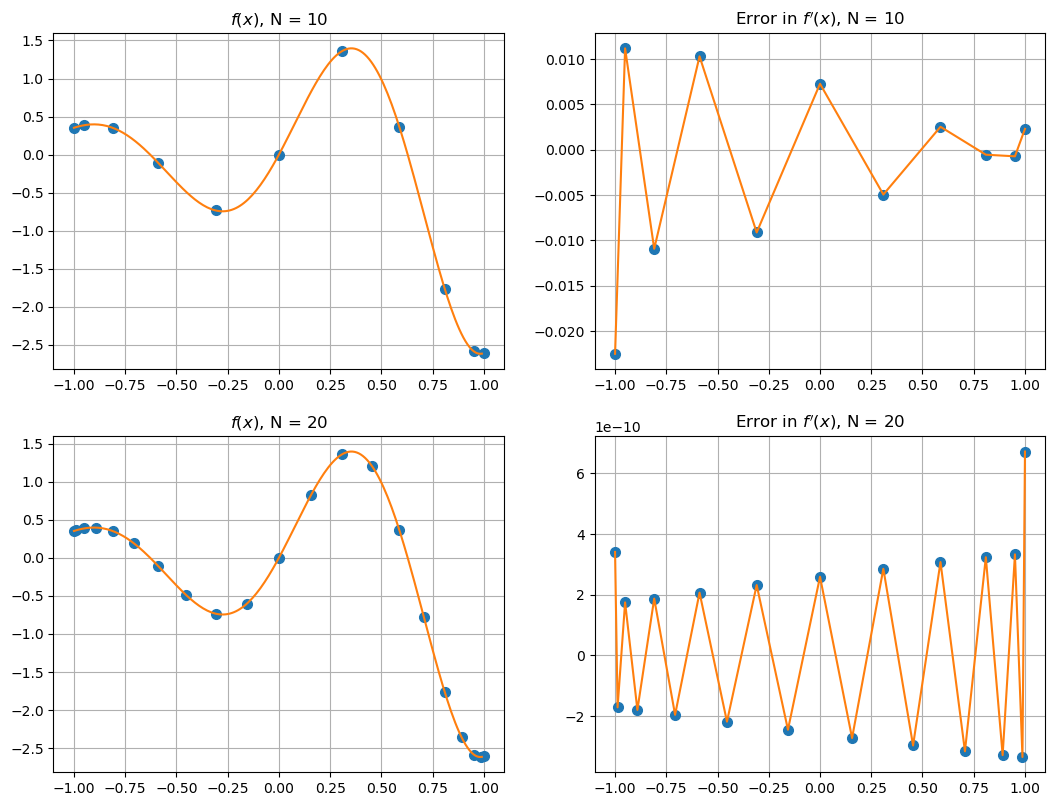

In [205]:
# Adaptation of program 18 in Trefethen
f = lambda x: numpy.exp(x) * numpy.sin(5.0 * x)  
# fungsi uji f(x) = e^x * sin(5x)

f_prime = lambda x: numpy.exp(x) * (numpy.sin(5.0 * x) + 5.0 * numpy.cos(5.0 * x))  
# turunan analitik f'(x) = e^x [sin(5x) + 5cos(5x)]

x_fine = numpy.arange(-1, 1, 0.01)  # grid halus untuk evaluasi fungsi

fig, axes = plt.subplots(2, 2)  # figure dengan 2x2 subplot
fig.set_figwidth(fig.get_figwidth() * 2)  # perbesar lebar figure
fig.set_figheight(fig.get_figheight() * 2)  # perbesar tinggi figure

for (i, N) in enumerate((10, 20)):  # loop untuk dua jumlah titik Chebyshev
    x = numpy.cos(numpy.pi * numpy.arange(N+1) / N)  # titik Chebyshev
    
    # Plot fungsi f(x)
    axes[i, 0].plot(x, f(x), '.', markersize=14)  # nilai f(x) di titik Chebyshev
    axes[i, 0].plot(x_fine, f(x_fine))  # kurva halus f(x)
    axes[i, 0].grid(True)
    axes[i, 0].set_title("$f(x)$, N = %s" % N)

    # Hitung error turunan dengan chebfft
    error = chebfft(f(x)) - f_prime(x)  # selisih antara turunan numerik dan analitik
    
    # Plot error
    axes[i, 1].plot(x, error, '.', markersize=14)  # error di titik Chebyshev
    axes[i, 1].plot(x, error)  # garis error
    axes[i, 1].grid(True)
    axes[i, 1].set_title("Error in $f'(x)$, N = %s" % N)

Kita juga dapat menerapkan metode-metode ini untuk menyelesaikan PDE dengan metode spektral Chebyshev pada arah spasial dan beberapa diskretisasi waktu pada arah waktu. Pertimbangkan persamaan gelombang orde kedua
$$
    u_{tt} = u_{xx}
$$
pada $\Omega = [-1, 1]$ dengan kondisi batas $0$. Kita akan kembali menggunakan leapfrog untuk integrasi waktu.

(81,) 161 81


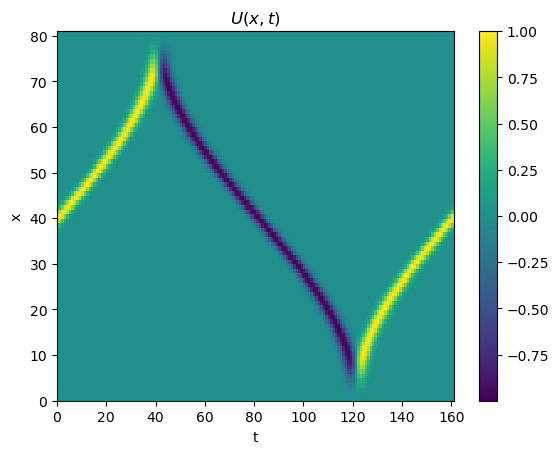

In [206]:
# Based on program 19 of Trefethen
# Solve the 2nd order wave equation on Chebyshev grid via leapfrog

N = 80  # jumlah titik Chebyshev
x = numpy.cos(numpy.pi * numpy.arange(0, N+1) / N)  # grid Chebyshev
delta_t = 8.0 / N**2  # langkah waktu stabil (CFL condition)
U = numpy.exp(-200.0 * x**2)  # kondisi awal (Gaussian centered di 0)
U_old = numpy.exp(-200.0 * (x - delta_t)**2)  # kondisi awal satu langkah ke belakang
t_final = 4.0  # waktu simulasi akhir

num_steps = int(numpy.ceil(t_final / delta_t))  # jumlah langkah waktu
plot_interval = 20  # interval output
t = 0.0
num_output = int(num_steps / plot_interval) + 1  # jumlah frame output
t_output = numpy.empty(num_output)  # array waktu output
t_output[0] = 0.0
U_output = numpy.empty((x.shape[0], num_output))  # array solusi output
U_output[:, 0] = U.copy()
frame = 1

# Loop waktu dengan metode leapfrog
for n in range(num_steps):
    U_hat_dbl_prime = chebfft(chebfft(U))  # turunan kedua via Chebyshev FFT
    U_hat_dbl_prime[0] = 0.0  # boundary condition u''(-1)=0
    U_hat_dbl_prime[-1] = 0.0  # boundary condition u''(1)=0
    
    U_new = 2.0 * U - U_old + delta_t**2 * U_hat_dbl_prime  # skema leapfrog
    U_old = U.copy()
    U = U_new

    t += delta_t
    if numpy.mod(n, plot_interval) == 0:  # simpan output setiap interval
        t_output[frame] = t
        U_output[:, frame] = U.copy()
        frame += 1

# Plot hasil
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
print(x.shape, len(t_output), len(U_output))  # cek dimensi
# plot = axes.pcolor(x, t_output, U_output)  # pcolor dengan x,t sebagai grid
plot = axes.pcolor(U_output)  # pcolor sederhana (matrix output)
axes.set_xlabel("t")
axes.set_ylabel("x")
axes.set_title("$U(x,t)$")
fig.colorbar(plot)

plt.show()

## Kuadratur Spektral

Salah satu konsekuensi paling kuat dari banyak hal yang telah kita lakukan sebenarnya terlihat melalui integral. Karena integral adalah operasi yang melicinkan, mungkin tidak terlalu mengejutkan bahwa ini menjadi kasus.

Jika kita ingin mengaproksimasi integral
$$
    I = \int^1_{-1} f(x) dx
$$
salah satu caranya adalah mencari interpolan polinomial $f(x)$ dan mengintegralkannya. Ini dikenal sebagai kuadratur Clenshaw-Curtis dan memiliki orde optimal pada himpunan titik Chebyshev yang tetap.

Kita akan mengikuti proses yang kita gunakan untuk menghubungkan FFT ke deret Chebyshev sehingga kita memiliki
$$\begin{aligned}
    \int^1_{-1} p(x) dx &= \int^1_{-1} p(z) \frac{dx}{dz} dz \\
    &= \frac{1}{4} \sum^N_{n=0} a_n \int^1_{-1} (z^n + z^{-n}) (1 - z^{-2}) dz\\
    &= \frac{1}{4} \sum^N_{n=0} a_n \int^1_{-1} (z^n - z^{n - 2} + z^{-n} - z^{-n - 2}) dz \\
    &= \frac{1}{4} \sum^N_{n=0} a_n \left(\left. \frac{z^{n+1} + z^{-n-1}}{n+1} \right |^1_{-1} - \left. \frac{z^{n-1} + z^{-n+1}}{n-1} \right |^1_{-1} \right) \\
    &= \sum^N_{n=0, n \text{even}} a_n \left(\frac{1}{n+1} - {1}{n - 1}\right) \\
    &= \sum^N_{n=0, n \text{even}} \frac{2a_n}{1 - n^2}.
\end{aligned}$$
Dengan ini kita menggunakan FFT untuk menentukan $a_n$ seperti yang dijelaskan sebelumnya.

In [207]:
def cheb_diff(N):
    """Compute the inverse differentiation matrix and return the x locations."""
    D, x = cheb(N)  # dapatkan matriks diferensiasi Chebyshev dan titik grid
    
    D_inv = numpy.linalg.inv(D[:-1, :-1])  
    # ambil submatriks D tanpa baris/kolom terakhir (boundary dihapus),
    # lalu hitung inversenya
    
    x = x[:-1]  
    # buang titik terakhir (biasanya boundary di x=-1 atau x=1)
    
    return D_inv, x  # kembalikan matriks invers diferensiasi dan titik grid interior

<>:37: SyntaxWarning: invalid escape sequence '\e'
<>:37: SyntaxWarning: invalid escape sequence '\e'
C:\Users\WIND11\AppData\Local\Temp\ipykernel_38304\4076445246.py:37: SyntaxWarning: invalid escape sequence '\e'
  titles = ['$|x^3|$', '$\exp(-x^{-2})$', '$1 / (1 + x^2)$', '$x^10$']


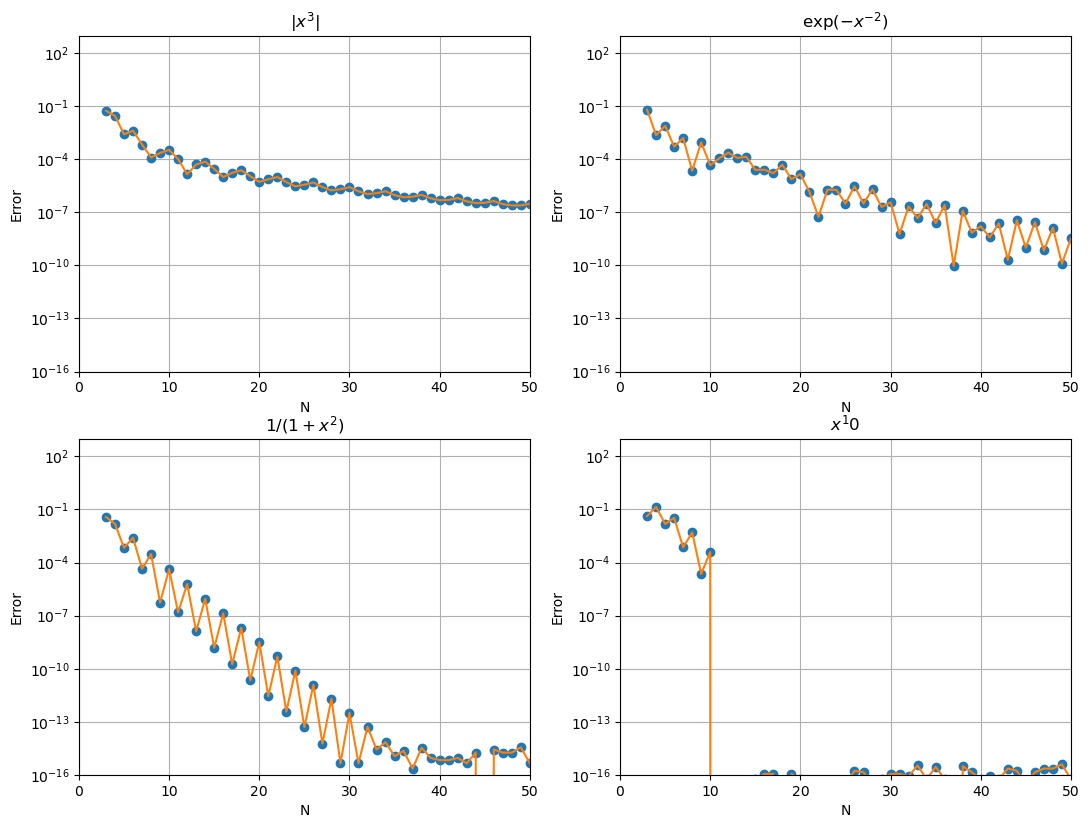

In [208]:
# Compare errors more carefully (program 30 in Trefethen)
#  Example directly uses Chebyshev differentiation matrix
import scipy.special  # untuk fungsi khusus (misalnya erf)

N_max = 50  # jumlah maksimum titik Chebyshev
error = numpy.zeros((4, N_max - 2))  # array untuk menyimpan error dari 4 fungsi uji
N_range = numpy.arange(3, N_max + 1)  # rentang N dari 3 sampai 50

for (i, N) in enumerate(N_range):
    D_inv, x = cheb_diff(N)  # inverse differentiation matrix dan titik grid interior
    
    # 1. Fungsi dengan turunan ketiga terbatas (bounded variation)
    f = numpy.abs(x)**3
    f_int = 0.5  # integral analitik ∫_{-1}^1 |x|^3 dx = 0.5
    error[0, i] = numpy.abs(numpy.dot(D_inv[0, :].transpose(), f) - f_int)

    # 2. Fungsi C∞ (halus tapi tidak analitik di 0)
    f = numpy.exp(-x**(-2))
    f_int = 2.0 * (numpy.exp(-1) + numpy.sqrt(numpy.pi) * (scipy.special.erf(1) - 1))  
    # integral analitik ∫_{-1}^1 e^{-1/x^2} dx
    error[1, i] = numpy.abs(numpy.dot(D_inv[0, :].transpose(), f) - f_int)

    # 3. Fungsi analitik di [-1,1]
    f = 1.0 / (1.0 + x**2)
    f_int = numpy.pi / 2.0  # integral analitik ∫_{-1}^1 1/(1+x^2) dx
    error[2, i] = numpy.abs(numpy.dot(D_inv[0, :].transpose(), f) - f_int)

    # 4. Polinomial sederhana
    f = x**10
    f_int = 2.0 / 11.0  # integral analitik ∫_{-1}^1 x^10 dx
    error[3, i] = numpy.abs(numpy.dot(D_inv[0, :].transpose(), f) - f_int)

# Plot errors
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
titles = ['$|x^3|$', '$\exp(-x^{-2})$', '$1 / (1 + x^2)$', '$x^10$']

for (i, title) in enumerate(titles):
    axes = fig.add_subplot(2, 2, i + 1)
    axes.semilogy(N_range, error[i, :], '.', markersize=12)  # plot error (titik)
    axes.semilogy(N_range, error[i, :])  # plot error (garis)
    axes.set_xlim((0, N_max))
    axes.set_ylim((1e-16, 1e3))  # skala log error
    axes.grid(True)
    axes.set_xlabel("N")  # jumlah titik Chebyshev
    axes.set_ylabel("Error")
    axes.set_title(title)  # judul subplot sesuai fungsi

In [209]:
def clencurt(N):
    theta = numpy.pi * numpy.arange(N + 1) / N  
    # sudut Chebyshev (θ_j = jπ/N)

    x = numpy.cos(theta)  
    # titik Chebyshev (x_j = cos(θ_j))

    w = numpy.zeros(N + 1)  
    # inisialisasi bobot integrasi Clenshaw–Curtis

    v = numpy.ones(N - 1)  
    # vektor untuk bobot interior

    if numpy.mod(N, 2) == 0:  # kasus N genap
        w[0] = 1.0 / (N**2 - 1.0)  # bobot di ujung kiri
        w[-1] = w[0]  # bobot di ujung kanan sama
        for k in range(N // 2):  # loop untuk menghitung koreksi bobot interior
            v -= 2.0 * numpy.cos(2.0 * k * theta[1:-1]) / (4.0 * k**2 - 1.0)
        v -= numpy.cos(N * theta[1:-1]) / (N**2 - 1.0)  # koreksi tambahan untuk N genap
    else:  # kasus N ganjil
        w[0] = 1.0 / N**2  # bobot di ujung kiri
        w[-1] = w[0]  # bobot di ujung kanan sama
        for k in range((N - 1) // 2 + 1):  # loop untuk bobot interior
            v -= 2.0 * numpy.cos(2.0 * k * theta[1:-1]) / (4.0 * k**2 - 1.0)

    w[1:-1] = 2.0 * v / N  
    # bobot interior dihitung dari vektor v

    return w, x  
    # kembalikan bobot Clenshaw–Curtis dan titik Chebyshev

<>:37: SyntaxWarning: invalid escape sequence '\e'
<>:37: SyntaxWarning: invalid escape sequence '\e'
C:\Users\WIND11\AppData\Local\Temp\ipykernel_38304\1106369279.py:37: SyntaxWarning: invalid escape sequence '\e'
  titles = ['$|x^3|$', '$\exp(-x^{-2})$', '$1 / (1 + x^2)$', '$x^10$']


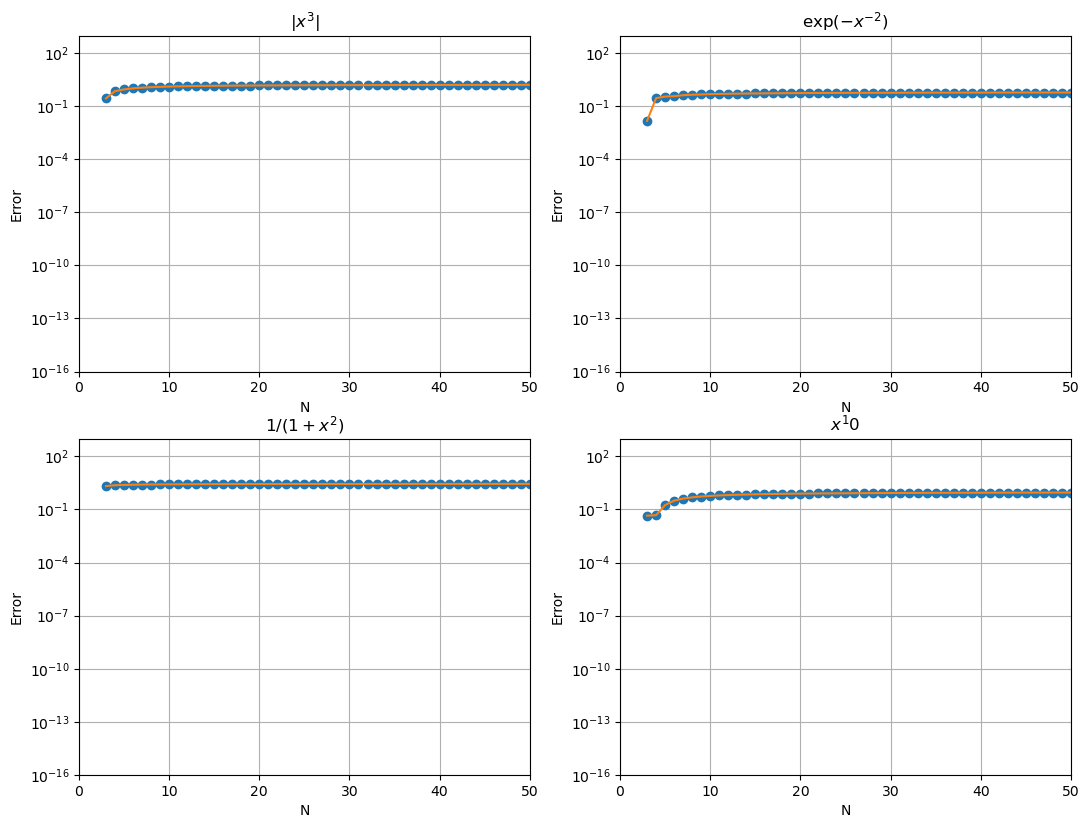

In [210]:
# Compare errors more carefully (program 30 in Trefethen)
#  Example using Clenshaw-Curtis quadrature weights
import scipy.special  # untuk fungsi khusus (misalnya erf)

N_max = 50  # jumlah maksimum titik Chebyshev
error = numpy.zeros((4, N_max - 2))  # array untuk menyimpan error dari 4 fungsi uji
N_range = numpy.arange(3, N_max + 1)  # rentang N dari 3 sampai 50

for (i, N) in enumerate(N_range):
    w, x = clencurt(N)  # bobot Clenshaw–Curtis dan titik Chebyshev
    
    # 1. Fungsi dengan turunan ketiga terbatas (bounded variation)
    f = numpy.abs(x)**3
    f_int = 0.5  # integral analitik ∫_{-1}^1 |x|^3 dx = 0.5
    error[0, i] = numpy.abs(numpy.dot(w, f) - f_int)

    # 2. Fungsi C∞ (halus tapi tidak analitik di 0)
    f = numpy.exp(-x**(-2))
    f_int = 2.0 * (numpy.exp(-1) + numpy.sqrt(numpy.pi) * (scipy.special.erf(1) - 1))  
    # integral analitik ∫_{-1}^1 e^{-1/x^2} dx
    error[1, i] = numpy.abs(numpy.dot(w, f) - f_int)

    # 3. Fungsi analitik di [-1,1]
    f = 1.0 / (1.0 + x**2)
    f_int = numpy.pi / 2.0  # integral analitik ∫_{-1}^1 1/(1+x^2) dx
    error[2, i] = numpy.abs(numpy.dot(w, f) - f_int)

    # 4. Polinomial sederhana
    f = x**10
    f_int = 2.0 / 11.0  # integral analitik ∫_{-1}^1 x^10 dx
    error[3, i] = numpy.abs(numpy.dot(w, f) - f_int)

# Plot errors
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
titles = ['$|x^3|$', '$\exp(-x^{-2})$', '$1 / (1 + x^2)$', '$x^10$']

for (i, title) in enumerate(titles):
    axes = fig.add_subplot(2, 2, i + 1)
    axes.semilogy(N_range, error[i, :], '.', markersize=12)  # plot error (titik)
    axes.semilogy(N_range, error[i, :])  # plot error (garis)
    axes.set_xlim((0, N_max))
    axes.set_ylim((1e-16, 1e3))  # skala log error
    axes.grid(True)
    axes.set_xlabel("N")  # jumlah titik Chebyshev
    axes.set_ylabel("Error")
    axes.set_title(title)  # judul subplot sesuai fungsi

In [211]:
def gauss(N):
    beta = 0.5 / numpy.sqrt(1.0 - (2.0 * numpy.arange(1, N))**(-2))  
    # parameter beta untuk matriks Jacobi (berhubungan dengan polinomial Legendre)

    T = numpy.diag(beta, 1) + numpy.diag(beta, -1)  
    # matriks tridiagonal simetris (Jacobi matrix)

    x, V = numpy.linalg.eig(T)  
    # eigen-dekomposisi: x = eigenvalues (titik Gauss), V = eigenvectors

    i = numpy.argsort(x)  
    # urutkan eigenvalues (titik Gauss) dari kecil ke besar

    x = x[i]  
    # titik Gauss-Legendre (roots of Legendre polynomial)

    w = 2.0 * V[0, i]**2  
    # bobot Gauss-Legendre quadrature dihitung dari eigenvector pertama

    return w, x  
    # kembalikan bobot dan titik Gauss-Legendre

<>:37: SyntaxWarning: invalid escape sequence '\e'
<>:37: SyntaxWarning: invalid escape sequence '\e'
C:\Users\WIND11\AppData\Local\Temp\ipykernel_38304\3910767064.py:37: SyntaxWarning: invalid escape sequence '\e'
  titles = ['$|x^3|$', '$\exp(-x^{-2})$', '$1 / (1 + x^2)$', '$x^10$']


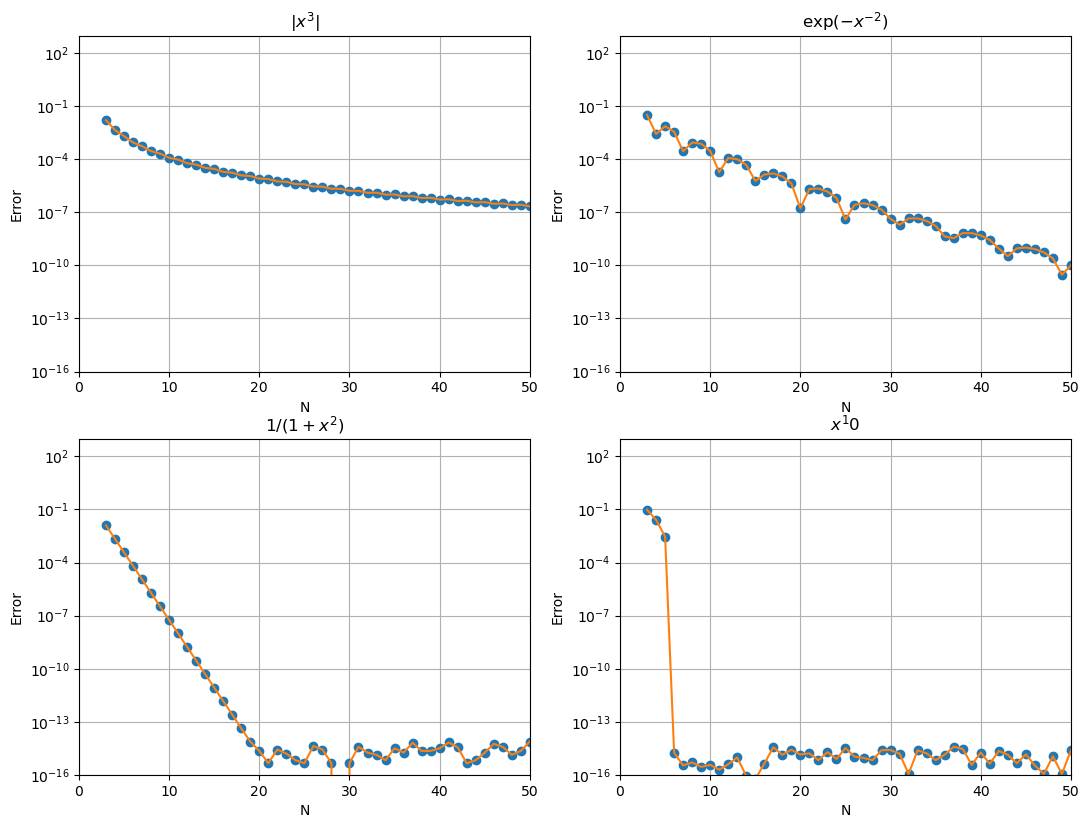

In [212]:
# Compare errors more carefully (program 30 in Trefethen)
#  Example using Gaussian quadrature (using Legendre points)
import scipy.special  # untuk fungsi khusus (misalnya erf)

N_max = 50  # jumlah maksimum titik Gauss-Legendre
error = numpy.zeros((4, N_max - 2))  # array untuk menyimpan error dari 4 fungsi uji
N_range = numpy.arange(3, N_max + 1)  # rentang N dari 3 sampai 50

for (i, N) in enumerate(N_range):
    w, x = gauss(N)  # bobot dan titik Gauss-Legendre
    
    # 1. Fungsi dengan turunan ketiga terbatas (bounded variation)
    f = numpy.abs(x)**3
    f_int = 0.5  # integral analitik ∫_{-1}^1 |x|^3 dx = 0.5
    error[0, i] = numpy.abs(numpy.dot(w, f) - f_int)

    # 2. Fungsi C∞ (halus tapi tidak analitik di 0)
    f = numpy.exp(-x**(-2))
    f_int = 2.0 * (numpy.exp(-1) + numpy.sqrt(numpy.pi) * (scipy.special.erf(1) - 1))  
    # integral analitik ∫_{-1}^1 e^{-1/x^2} dx
    error[1, i] = numpy.abs(numpy.dot(w, f) - f_int)

    # 3. Fungsi analitik di [-1,1]
    f = 1.0 / (1.0 + x**2)
    f_int = numpy.pi / 2.0  # integral analitik ∫_{-1}^1 1/(1+x^2) dx
    error[2, i] = numpy.abs(numpy.dot(w, f) - f_int)

    # 4. Polinomial sederhana
    f = x**10
    f_int = 2.0 / 11.0  # integral analitik ∫_{-1}^1 x^10 dx
    error[3, i] = numpy.abs(numpy.dot(w, f) - f_int)

# Plot errors
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
titles = ['$|x^3|$', '$\exp(-x^{-2})$', '$1 / (1 + x^2)$', '$x^10$']

for (i, title) in enumerate(titles):
    axes = fig.add_subplot(2, 2, i + 1)
    axes.semilogy(N_range, error[i, :], '.', markersize=12)  # plot error (titik)
    axes.semilogy(N_range, error[i, :])  # plot error (garis)
    axes.set_xlim((0, N_max))
    axes.set_ylim((1e-16, 1e3))  # skala log error
    axes.grid(True)
    axes.set_xlabel("N")  # jumlah titik Gauss-Legendre
    axes.set_ylabel("Error")
    axes.set_title(title)  # judul subplot sesuai fungsi